# 🛒 **E-Commerce Customer Churn Prediction**


## **1. Business Problem Understanding**

### **1.1 Background and Market Context**

The Indian e-commerce market has moved rapidly **from a foundational growth phase to a retention-driven phase.** With over 800 million active internet users and high smartphone penetration, India’s e-commerce sector is projected to exceed USD 200 billion in valuation by 2026 (tunjukin statistik ini di ppt background). Early expansion strategies focused on capturing new users through heavy discounting and logistics investment. However, growth from Tier-1 and Tier-2 urban markets has plateaued (tunjukin graph ini di ppt), increasing pressure on platforms to **derive profitability from existing customers** rather than new sign-ups.

In the current landscape, **customer retention and churn prevention have become far more strategic priorities.** Acquiring a new customer in India’s highly competitive consumer environment has become costly. Industry data suggests that Customer Acquisition Cost (CAC) for an electronics buyer often ranges between ₹800 and ₹1,500 (USD 10–20), and can spike above ₹2,500 (USD 30+) in premium segments or outside major sale events. However, net margins in consumer electronics are typically very thin (0.5 %–3 %) after logistics and overheads, meaning the first transaction often contributes little or no profit. **Customers only become truly profitable from their repeat purchases over time.**

Besides that, consumer behavior in India is shifting under competitive pressures from Quick commerce players (i.e. Blinkit, Zepto, Swiggy) and deep-discount marketplaces fighting over price-sensitive customers. This shifted churn to be less about inactivity and more about **migration of CLV to competitors** offerng marginally better price or service.

**Flopkart**\
Flopkart is one of India’s largest and most influential e-commerce platforms, selling a wide range of products including electronics, fashion, appliances, and groceries. While flanked by competitors like Amazon India and emerging regional players, Flopkart’s strengths lie in its developed logistical infrastructure and strong brand recognition. However, the company faces persistent challenges in retaining high-value customers, managing rising customer acquisition costs, and navigating intensified competition from Q-commerce players.

**tldr buat pemahaman dan ngejelasin:**\
e-commerce india udah matang -> biar kompetitif dan tetap untung bukan customer acquisition lagi -> perlunya adalah customer biar TERUS balik dan belanja ke kita (retention)

### **1.2 Defining Churn**
The churn definition used in this project was established through extensive evaluation of the dataset’s behavioral, transactional, and experiential variables, combined with contextual knowledge of large-scale Indian e-commerce platforms. Our reasoning process is outlined below. Please refer to EDA chapter for the analyses presented in this segment.

- **Behavioral inconsistency with inactivity-based churn**\
Customers labeled as churned are observed to have DaySinceLastOrder = 0, non-zero OrderCount, and measurable engagement levels. This directly contradicts standard inactivity-based churn definitions, where churned users would exhibit prolonged absence of transactions or engagement.
- **Incompatibility with explicit cancellation models**\
Dataset context suggests that churn is unlikely to be triggered by traditional explicit user actions. Indian e-commerce does not typically use traditional time-based renewing subscriptions (Think Netflix, Spotify) or require formal account termination to trigger a churn flag. Cart Abandonment Rate (CAR) and Mobile App Uninstall Rate are other possible explicit triggers, but the absence of their respective features in the dataset eliminate those triggers from our model.
    | Traditional Churn | This Dataset |  
    |---|---|
    | Binary: canceled or not | Spectrum: customer can be active but flagged |
    | Backward-looking ("User have churned") | Forward-looking ("User is at risk") |
    | Triggered by explicit action | Inferred from behavioral signals |
    | Measures transaction | Measures relationship health |\ 

- **Presence of customer experience indicators**\
Variables such as SatisfactionScore, Complain, WarehouseToHome, and CashbackAmount indicate that customer experience, service quality, and incentive dependency are central to the dataset’s structure. These features are more commonly used in retention risk assessment than in inactivity labeling.
- **Temporal Mismatch between churn and transactional activity**\
Metrics such as OrderAmountHikeFromLastYear operate on a trailing historical basis, while OrderCount and DaySinceLastOrder reflect recent activity. The presence of churned users with positive historical growth suggests that churn is determined by forward-looking retention expectations rather than short-term behavior.
- **Churn does not necessarily indicate a lost customer.**\
From a commercial perspective, customers may continue to transact despite being classified as churning/having low-lifetime-value due to declining engagement quality, repeated complaints, high service costs, or price-sensitive behavior. This aligns with how churn flags operate in CRM and marketing systems.

**In conclusion,** churn represents an algorithm-assisted, **business-defined customer label** that indicates:
- Churn: **This customer is unlikely to sustain long-term engagement in the future.**
- Not churn: **This customer will most likely sustain long-term engagement in the future.**

Churn **does NOT mean:**
- Customer deletes their account
- Customer uninstalls the app on their phone
- Customer explicitly presses an "Unsubscribe" button
- Customer will never return and generate revenue for the company ever again

The churn flag **should not be interpreted as a definitive indicator of realized customer loss** or immediate revenue loss (“X churned customers implies Y revenue loss”). Instead, the churn flag is used to interpret customer retention and risk segment based on a combined evaluation of behavioral trends and historical performance metrics.



### **1.3 Problem Statement**

Customer churn presents a critical resource allocation challenge for e-commerce platforms. While churn itself reflects declining engagement and long-term customer value, the primary threat lies in the **limitation of marketing and retention resources.** Retention interventions such as promotions, discounts, and outreach require significant amount of costs, making indiscriminate efforts economically unsustainable. 

In non-subscription e-commerce contexts such as Flopkart, churn is rarely triggered by a single explicit action. Instead, it is inferred from patterns of behavioral, engagement, and transactional signals. As a result, churn classification is a decision-enabling mechanism used to **prioritize which customers require proactive intervention.** Therefore, failing to identify churning customers lead to **high economic consequences in the form of lost future customer value.**

This project aims to analyze key behavioral features associated with customer churn classification and to develop a model that accurately predicts customers at high-risk of churning. By enabling more targeted interventions, the model supports a more accurate and efficient retention efforts and resource allocation.

Target:
- 0 : Customer does not churn
- 1 : Customer churns

**Stakeholder**: Flopkart's Marketing and Strategy team.\
**Our role**: Flopkart's Data Science team.

**Objectives**

1. Develop a churn classification model to identify customers at high-risk of churn with optimization towards minimizing False Negatives (i.e., avoiding missed high-risk churners)
2. Identify and quantify the key behavioral and engagement factors associated with elevated churn risk.
3. Deliver a robust and deployable churn risk model that can be utilized by marketing and strategy teams to support decision-making.

### **1.4 Analytical Approach**

This project employs a structured analytical approach combining exploratory data analysis and supervised classification models to address customer churn at Flopkart. The analysis begins with data cleaning and exploration to identify behavioral and transactional patterns associated with churn. Based on these insights, a classification machine learning model is developed to predict customer churn, and feature importance analysis is conducted to identify key factors influencing churn and support data-driven retention strategies.

This project adopts a structured analytical approach that combines exploratory data analysis with supervised classification modeling to support cost-aware churn management at Flopkart. Following data cleaning and behavioral analysis, a churn classification model is developed to classify customers by their churn risk, enabling retention efforts to be **focused on customers where wrong classfication is most expensive.** Model outputs are accompanied with feature importance analysis to show the behavioral drivers of churn risk.

### **1.5 Evaluation Metric Selection**
We try to assign plausible monetary costs to classification outcomes based on Indian e-commerce market realities (2024–2025).

Assumptions:
- USD conversion: For simplicity assume ₹85 ≈ $1 (approx. 2025 macro FX levels, will be rounded up)
- Category considered for cost matrix is Electronics (Laptops, phones, accessories)

#### **1. Cost of False Negatives**
False negative is the condition where the model predicts a customer will stay when they will actually churn. The cost is a combination of:
- Immediate loss of future contribution margin from the churned customer (Lost Margin)
- The acquisition cost needed to replace the lost customer (CAC).

The details are as follows:
1. **Average Order Value (AOV):**\
 Weighted average for an "active" electronics shopper is ₹5,000 or **around USD 55.**
2.  **Gross Margin (AOV * margin):**\
 Retail margins in electronics are typically 10-15%. ₹5,000 * 10 or 15% = ₹750 or **around USD 7,5.**
3.  **Annual Gross Margin (Frequency * Gross Margin):**\
 An active user might make 2 electronics purchases a year. ₹750 * 2 = ₹1,500 or **around USD 15.**
4.  **Lost Margin (Annual Gross Margin * Cust. lifetime):** Assuming a 3-year life, the Lost Margin is ₹1,500 * 3 = ₹4,500  or **around USD 45.**
6. **Replacement Cost (CAC)**: Customer Acquisition Cost is ~₹1,000 - ₹1,500 or around USD 13.

$$
\text{Total FN Cost} = \text{Lost Margin }(\$45) + \text{ CAC }(\$13) = \mathbf{\$58} (\mathbf{\text{rounded to \$60}})
$$

#### **2. Cost of False Positives**
False positive is the condition where the model predicts a customer is at risk of churning when they are actually a stable and consistent customer of the company.
- **Communication cost:** Digital marketing via SMS/WhatsApp costs ~$0.01–$0.10 per message.
- **Incentive cost:** Retention coupons might be a fixed discount or percentage rebate applied to the next purchase. At an AOV of ~$55, a 5%–10% discount (~$3–$6) is realistic to prevent churn.

$$
\text{Total FP Cost} = \text{Communication }(\$0.05) + \text{ Incentives }(\$4.5) = \mathbf{\$4.5} (\mathbf{\text{rounded to \$5}})
$$

#### **3. The Asymmetry Ratio**
$$
\text{Asymmetry Ratio} = \frac{\text{Cost of FN }(\$60)}{\text{Cost of FP }(\$5)} = \mathbf{12:1}
$$


Missing one truly churn risk (FP) customer is as costly as running 14 unnecessary retention actions (FN). This means false negatives are significantly more dangerous than false positives and a high-recall score prediction is required. Based on this requirement, **F2-score is the main evaluation metric used.**

#### **4. Precision Floor & Marketing ROI**

The precision floor is the minimum precision required for a retention campaign to break even and make sense financially.

$$
\text{Precision Floor} = \frac{\text{Cost of FP }(\$5)}{\text{Cost of FN }(\$60)} = \mathbf{\text{\%8,4}}
$$


**Supporting Metrics:**

Precision–Recall AUC (PR AUC) is used as a supporting metric to evaluate the model’s ability to correctly rank customers at risk of churn in an imbalanced dataset. While F2-score is used as the primary decision metric to explicitly prioritize recall and minimize False Negatives based on business cost considerations, PR AUC provides a complementary view of the model’s overall discrimination power and stability across thresholds.

Sources:
- [The Rapid Growth of India's Ecommerce Market](https://paymentscmi.com/insights/india-ecommerce-market-growth-trends/)
- [India E-Commerce Market Size & Share Analysis - Growth Trends and Forecast (2026 - 2031)](https://www.mordorintelligence.com/industry-reports/india-ecommerce-market)
- [India E-Commerce Market By Product, By Model Type, By Region, Competition, Forecast & Opportunities, 2021-2031F](https://www.techsciresearch.com/report/india-e-commerce-market/27488.html)
- [Indian E-Commerce Industry Analysis](https://www.ibef.org/industry/ecommerce-presentation)
- [E-commerce App Retention Trends India (2022)](https://www.moengage.com/industry-reports/e-commerce-app-retention-trends-india/#)
- [Electronics Industry in India](https://ecdb.com/resources/sample-data/market/in/electronics)
- [India Goes Digital](https://www.scribd.com/document/242245602/India-Goes-Digital)
- [An ingredient for this curry is missing - and in eight minutes it's at the door)](https://www.bbc.com/news/articles/cvgx7ykl12go)

In [1]:
import numpy as np
import time
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.ticker as mtick
from skrub import TableReport
from scipy.stats import chi2_contingency

import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder
from category_encoders import OrdinalEncoder
from category_encoders.binary import BinaryEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold, KFold,cross_val_score, cross_validate

from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
# from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, fbeta_score, make_scorer

import warnings
warnings.filterwarnings('ignore')

# Set max columns
pd.set_option('display.max_columns', None)

# save pickle
from inspect import getblock
import pickle

## **2. Load Dataset**

In [2]:
#Directory Dictionary
dir_ojan = r"C:\Users\mariq\Documents\2. KERJA\Purwadika\Final Project\E Commerce Dataset only.csv"
dir_rafi = r"C:\Users\rafipriyahutama\OneDrive\Documents\Purwadhika\Final_Project\Dataset\archive\ecom_pisah.xlsx"
dir_anov = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')

#import data
dir = dir_anov
df = dir

df.head(10)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


### **2.1 Data Understanding**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [4]:
pd.set_option('display.max_colwidth', 0)
list_item = []
for col in df.columns :
    list_item.append( [col, df[col].nunique(), df[col].unique()])

info_tabel = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                     data=list_item)
info_tabel

,Column Name,Number of Unique,Unique Sample
0,CustomerID,5630,"[50001, 50002, 50003, 50004, 50005, 50006, 50007, 50008, 50009, 50010, 50011, 50012, 50013, 50014, 50015, 50016, 50017, 50018, 50019, 50020, 50021, 50022, 50023, 50024, 50025, 50026, 50027, 50028, 50029, 50030, 50031, 50032, 50033, 50034, 50035, 50036, 50037, 50038, 50039, 50040, 50041, 50042, 50043, 50044, 50045, 50046, 50047, 50048, 50049, 50050, 50051, 50052, 50053, 50054, 50055, 50056, 50057, 50058, 50059, 50060, 50061, 50062, 50063, 50064, 50065, 50066, 50067, 50068, 50069, 50070, 50071, 50072, 50073, 50074, 50075, 50076, 50077, 50078, 50079, 50080, 50081, 50082, 50083, 50084, 50085, 50086, 50087, 50088, 50089, 50090, 50091, 50092, 50093, 50094, 50095, 50096, 50097, 50098, 50099, 50100, ...]"
1,Churn,2,"[1, 0]"
2,Tenure,36,"[4.0, nan, 0.0, 13.0, 11.0, 9.0, 19.0, 20.0, 14.0, 8.0, 18.0, 5.0, 2.0, 30.0, 1.0, 23.0, 3.0, 29.0, 6.0, 26.0, 28.0, 7.0, 24.0, 25.0, 10.0, 15.0, 22.0, 27.0, 16.0, 12.0, 21.0, 17.0, 50.0, 60.0, 31.0, 51.0, 61.0]"
3,PreferredLoginDevice,3,"[Mobile Phone, Phone, Computer]"
4,CityTier,3,"[3, 1, 2]"
5,WarehouseToHome,34,"[6.0, 8.0, 30.0, 15.0, 12.0, 22.0, 11.0, 9.0, 31.0, 18.0, 13.0, 20.0, 29.0, 28.0, 26.0, 14.0, nan, 10.0, 27.0, 17.0, 23.0, 33.0, 19.0, 35.0, 24.0, 16.0, 25.0, 32.0, 34.0, 5.0, 21.0, 126.0, 7.0, 36.0, 127.0]"
6,PreferredPaymentMode,7,"[Debit Card, UPI, CC, Cash on Delivery, E wallet, COD, Credit Card]"
7,Gender,2,"[Female, Male]"
8,HourSpendOnApp,6,"[3.0, 2.0, nan, 1.0, 0.0, 4.0, 5.0]"
9,NumberOfDeviceRegistered,6,"[3, 4, 5, 2, 1, 6]"


### **2.2 Data Overview**

**Data Dictionary**

| Feature | Description | Notes |
|--------|------------|-------|
| CustomerID | Unique customer ID | Integer. Will drop |
| Churn | Churn flag (1 = churn, 0 = no churn) | Boolean/Int. Target feature |
| Tenure | Tenure of customer with the company in months (since sign-up) | Integer. RobustScaler |
| PreferredLoginDevice | Preferred login device of customer | String. OneHotEncoder |
| CityTier | Level of urbanization (1 = Metropolitan hubs, 2 = Emerging centers, 3 = Developing cities) | Integer. OrdinalEncoding |
| WarehouseToHome | Distance from warehouse to customer (km) | Integer. RobustScaler |
| PreferredPaymentMode | Preferred payment method of customer | String. OneHotEncoder |
| Gender | Gender of customer | String. OneHotEncoder |
| HourSpendOnApp | User engagement in past month (scale 0–5; higher = more time spent) | Integer. RobustScaler |
| NumberOfDeviceRegistered | Total number of devices registered by customer | Integer. RobustScaler |
| PreferedOrderCat | Preferred order category in last month | String. OneHotEncoder |
| SatisfactionScore | Customer-reported satisfaction score (1–5), based on recent interaction | Integer. OrdinalEncoding |
| MaritalStatus | Marital status of customer | String. OneHotEncoder |
| NumberOfAddress | Total number of addresses added by customer | Integer. RobustScaler |
| Complain | Complaint raised in last month (1 = yes, 0 = no) | Boolean/Int. No scaling needed |
| OrderAmountHikeFromlastYear | Trailing 12-month order growth; capped/winsorized, no negative values | Integer. RobustScaler |
| CouponUsed | Total number of coupons used in last month | Integer. RobustScaler |
| OrderCount | Total number of orders placed in last month | Integer. RobustScaler |
| DaySinceLastOrder | Days since last order | Integer. RobustScaler |
| CashbackAmount | Average cashback/incentives in last month | Integer. RobustScaler |

### **2.3 Data Cleaning**

Figure out data types, their dimensions, and identify missing values & duplicates.

In [5]:
TableReport(df)

Processing column  20 / 20


,,,,,,,,,,,,,,,,,,,,


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

Data Overview:
- Consists of 5630 rows and 20 columns.
- Has 18 features with 1 target feature (churn)

In [7]:
df.describe(include="all")

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630,5630.000000,5379.000000,5630,5630,5375.000000,5630.000000,5630,5630.000000,5630,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
unique,NaN,NaN,NaN,3,NaN,NaN,7,2,NaN,NaN,6,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Mobile Phone,NaN,NaN,Debit Card,Male,NaN,NaN,Laptop & Accessory,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2765,NaN,NaN,2314,3384,NaN,NaN,2050,NaN,2986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,52815.500000,0.168384,10.189899,NaN,1.654707,15.639896,NaN,NaN,2.931535,3.688988,NaN,3.066785,NaN,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,NaN,0.915389,8.531475,NaN,NaN,0.721926,1.023999,NaN,1.380194,NaN,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,NaN,1.000000,5.000000,NaN,NaN,0.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,NaN,1.000000,9.000000,NaN,NaN,2.000000,3.000000,NaN,2.000000,NaN,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,NaN,1.000000,14.000000,NaN,NaN,3.000000,4.000000,NaN,3.000000,NaN,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,NaN,3.000000,20.000000,NaN,NaN,3.000000,4.000000,NaN,4.000000,NaN,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500


Redundant values summary:
- PreferredLoginDevice -> Mobile Phone to Phone
- PreferredPaymentMode -> Cash on Delivery to COD, Credit Card to CC
- PreferredOrderCat -> Mobile phone & Mobile to Phone

In [8]:
#Mobile Phone to Phone
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Mobile Phone', 'Phone')
df['PreferredLoginDevice'].unique()

array(['Phone', 'Computer'], dtype=object)

In [9]:
#Cash on Delivery to COD
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace('Cash on Delivery', 'COD')
#change Credit Card to CC
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace('Credit Card', 'CC')
df['PreferredPaymentMode'].unique()

array(['Debit Card', 'UPI', 'CC', 'COD', 'E wallet'], dtype=object)

In [10]:
#change Mobile Phone & Mobile to Phone
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile Phone', 'Phone')
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile', 'Phone')
df['PreferedOrderCat'].unique()

array(['Laptop & Accessory', 'Phone', 'Others', 'Fashion', 'Grocery'],
      dtype=object)

#### **Duplicated Rows Analysis**

In [11]:
df.duplicated().sum()

np.int64(0)

No duplicated rows.

#### **Anomaly Detection**

##### **Zero Recorded App Hours with Existing Orders**
HourSpendOnApp = 0 but OrderCount > 0

Ignored, because HourSpendOnApp is a binned value. Does not mean that user have not spent a second.

In [12]:
df[(df["HourSpendOnApp"] == 0) & (df["OrderCount"] > 0)]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
950,50951,0,5.0,Phone,1,16.0,CC,Male,0.0,3,Fashion,1,Single,3,0,25.0,0.0,1.0,NaN,212.44
1950,51951,0,11.0,Computer,1,18.0,Debit Card,Male,0.0,4,Laptop & Accessory,5,Married,3,0,15.0,1.0,1.0,2.0,162.88


##### **High App Engagement Without Recent Purchases**
HourSpendOnApp is great, but order count is 0 and day since last order is greater than 30. Could be an indicator of users that browse a lot but doesnt purchase anything.

In [13]:
df[(df["HourSpendOnApp"] >= 4) & (df["OrderCount"] == 0) & (df["DaySinceLastOrder"] > 30)]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount


##### **Transactional Activity with Zero Recorded Tenure**
Tenure = 0 but OrderCount > 0 \
Tenure = 0 but CouponUsed > 0 \
Tenure = 0 but Complain > 0

Ignored, these cases are still possible (multiple orders under a month, etc.)

In [14]:
df[(df["OrderCount"] > 0) & (df["Tenure"] == 0)]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
12,50013,1,0.0,Phone,1,11.0,COD,Male,2.0,3,Phone,3,Single,2,1,13.0,2.0,2.0,2.0,134.41
13,50014,1,0.0,Phone,1,15.0,CC,Male,3.0,4,Phone,3,Divorced,1,1,17.0,0.0,1.0,0.0,133.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2778,52779,0,0.0,Phone,3,14.0,UPI,Female,2.0,3,Laptop & Accessory,3,Married,1,1,22.0,0.0,1.0,4.0,149.07
2781,52782,0,0.0,Phone,3,NaN,CC,Male,2.0,3,Phone,5,Single,2,1,11.0,1.0,1.0,2.0,123.80
2787,52788,1,0.0,Phone,1,7.0,CC,Male,2.0,3,Phone,1,Married,10,1,14.0,2.0,2.0,2.0,147.87
2809,52810,0,0.0,Phone,3,11.0,UPI,Female,NaN,4,Phone,3,Single,1,0,18.0,1.0,1.0,0.0,129.66


What about extreme OrderCount amounts?

In [15]:
df[(df["OrderCount"] > 10) & (df["Tenure"] == 0)]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
570,50571,1,0.0,Phone,3,6.0,Debit Card,Male,2.0,4,Fashion,3,Divorced,6,0,11.0,1.0,11.0,7.0,206.09
627,50628,1,0.0,Phone,1,22.0,Debit Card,Female,NaN,1,Phone,5,Single,2,0,16.0,15.0,15.0,14.0,127.43
1659,51660,0,0.0,Phone,1,16.0,CC,Male,3.0,3,Grocery,5,Married,2,1,14.0,NaN,11.0,10.0,270.68
2040,52041,1,0.0,Phone,3,6.0,Debit Card,Male,2.0,4,Fashion,3,Married,6,0,11.0,5.0,11.0,46.0,206.09
2097,52098,1,0.0,Phone,1,22.0,Debit Card,Female,NaN,1,Phone,5,Single,2,0,16.0,3.0,15.0,14.0,127.43


In [16]:
df[(df["CouponUsed"] > 0) & (df["Tenure"] == 0)]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
12,50013,1,0.0,Phone,1,11.0,COD,Male,2.0,3,Phone,3,Single,2,1,13.0,2.0,2.0,2.0,134.41
16,50017,1,0.0,Computer,1,12.0,Debit Card,Female,NaN,4,Phone,2,Single,2,1,18.0,1.0,1.0,0.0,129.26
17,50018,1,0.0,Phone,3,11.0,E wallet,Male,2.0,4,Laptop & Accessory,3,Single,2,1,11.0,1.0,1.0,3.0,157.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2753,52754,0,0.0,Phone,1,NaN,UPI,Male,3.0,3,Phone,1,Single,2,0,13.0,1.0,1.0,4.0,126.47
2768,52769,0,0.0,Phone,1,7.0,Debit Card,Male,3.0,3,Phone,3,Single,1,0,12.0,1.0,1.0,2.0,133.75
2781,52782,0,0.0,Phone,3,NaN,CC,Male,2.0,3,Phone,5,Single,2,1,11.0,1.0,1.0,2.0,123.80
2787,52788,1,0.0,Phone,1,7.0,CC,Male,2.0,3,Phone,1,Married,10,1,14.0,2.0,2.0,2.0,147.87


In [17]:
df[(df["Complain"] > 0) & (df["Tenure"] == 0)]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
12,50013,1,0.0,Phone,1,11.0,COD,Male,2.0,3,Phone,3,Single,2,1,13.0,2.0,2.0,2.0,134.41
13,50014,1,0.0,Phone,1,15.0,CC,Male,3.0,4,Phone,3,Divorced,1,1,17.0,0.0,1.0,0.0,133.88
16,50017,1,0.0,Computer,1,12.0,Debit Card,Female,NaN,4,Phone,2,Single,2,1,18.0,1.0,1.0,0.0,129.26
17,50018,1,0.0,Phone,3,11.0,E wallet,Male,2.0,4,Laptop & Accessory,3,Single,2,1,11.0,1.0,1.0,3.0,157.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2758,52759,0,0.0,Phone,1,8.0,UPI,Male,2.0,3,Phone,3,Married,7,1,19.0,0.0,1.0,2.0,139.77
2778,52779,0,0.0,Phone,3,14.0,UPI,Female,2.0,3,Laptop & Accessory,3,Married,1,1,22.0,0.0,1.0,4.0,149.07
2781,52782,0,0.0,Phone,3,NaN,CC,Male,2.0,3,Phone,5,Single,2,1,11.0,1.0,1.0,2.0,123.80
2787,52788,1,0.0,Phone,1,7.0,CC,Male,2.0,3,Phone,1,Married,10,1,14.0,2.0,2.0,2.0,147.87


##### **More Coupons Used Than Orders**
More coupons used than amount of order.

Ignored, its possible for a single order to use multiple coupons, or not use any coupon at all.

In [18]:
df[(df["OrderCount"]) < (df["CouponUsed"])]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount


##### **Satisfaction Scores Without Completed Orders**
- SatisfactionScore exists but never finished any order
- SatisfactionScore exists but very low/no engagement with app

Ignored, both cases are possible since SatisfactionScore is not attached to finishing an order.

In [19]:
df[(df["SatisfactionScore"] > 0) & (df["OrderCount"] == 0)]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount


In [20]:
df[(df["SatisfactionScore"] > 0) & (df["HourSpendOnApp"] == 0)]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
150,50151,0,10.0,Computer,1,6.0,CC,Female,0.0,3,Fashion,2,Married,3,1,18.0,0.0,NaN,2.0,236.03
950,50951,0,5.0,Phone,1,16.0,CC,Male,0.0,3,Fashion,1,Single,3,0,25.0,0.0,1.0,NaN,212.44
1950,51951,0,11.0,Computer,1,18.0,Debit Card,Male,0.0,4,Laptop & Accessory,5,Married,3,0,15.0,1.0,1.0,2.0,162.88


##### **Complaint Count Exceeding Order Count**
More complains than amount of order is impossible.

In [21]:
df[(df["Complain"]) > (df["OrderCount"])]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount


##### **Order Growth from Last Year Without Current Orders**
OrderCount this month is 0 but OrderAmountHikeFromLastYear > 0.

Ignored, because order hike is 12 months trailing.

In [22]:
df[(df["OrderCount"] == 0) & (df["OrderAmountHikeFromlastYear"] > 0)]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount


In [23]:
df.to_csv('data_preprocessed.csv', index=False)

#### **Missing Value Analysis**

In [24]:
df.isna().sum()

CustomerID                     0  
Churn                          0  
Tenure                         264
PreferredLoginDevice           0  
CityTier                       0  
WarehouseToHome                251
PreferredPaymentMode           0  
Gender                         0  
HourSpendOnApp                 255
NumberOfDeviceRegistered       0  
PreferedOrderCat               0  
SatisfactionScore              0  
MaritalStatus                  0  
NumberOfAddress                0  
Complain                       0  
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                 0  
dtype: int64

7 features with missing values. We will analyze each feature and their missing values.

##### **Missing Value Heatmap Visualization**

In [25]:
missing_value = df.isnull().sum()
total_rows = len(df)

missing_df = pd.DataFrame({
    'Total Missing': missing_value,
    'Percentage (%)': (missing_value / total_rows) * 100
}).sort_values(by='Total Missing', ascending=False)

columns_with_nan = missing_df[missing_df['Total Missing'] > 0]
columns_with_nan

,Total Missing,Percentage (%)
DaySinceLastOrder,307,5.452931
OrderAmountHikeFromlastYear,265,4.706927
Tenure,264,4.689165
OrderCount,258,4.582593
CouponUsed,256,4.547069
HourSpendOnApp,255,4.529307
WarehouseToHome,251,4.458259


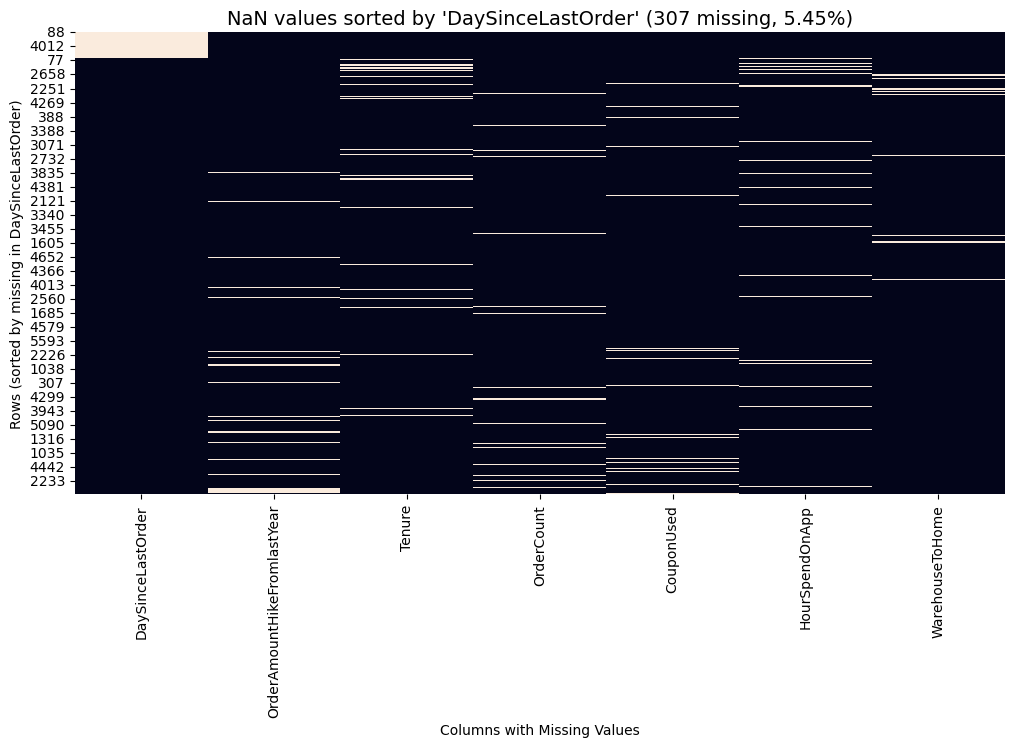

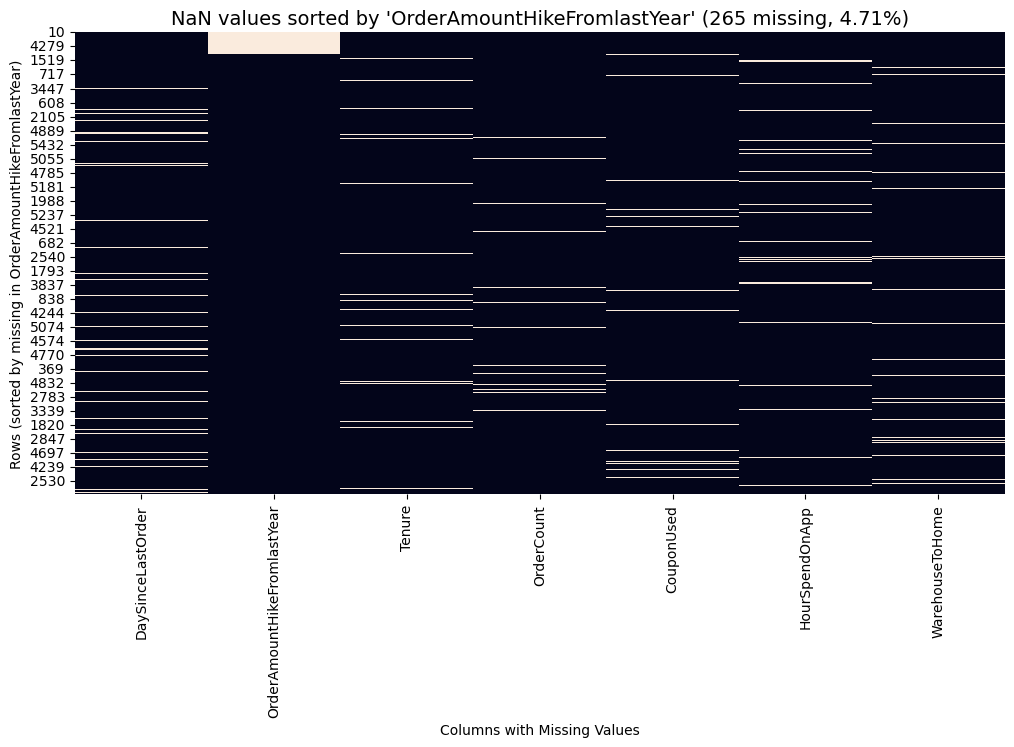

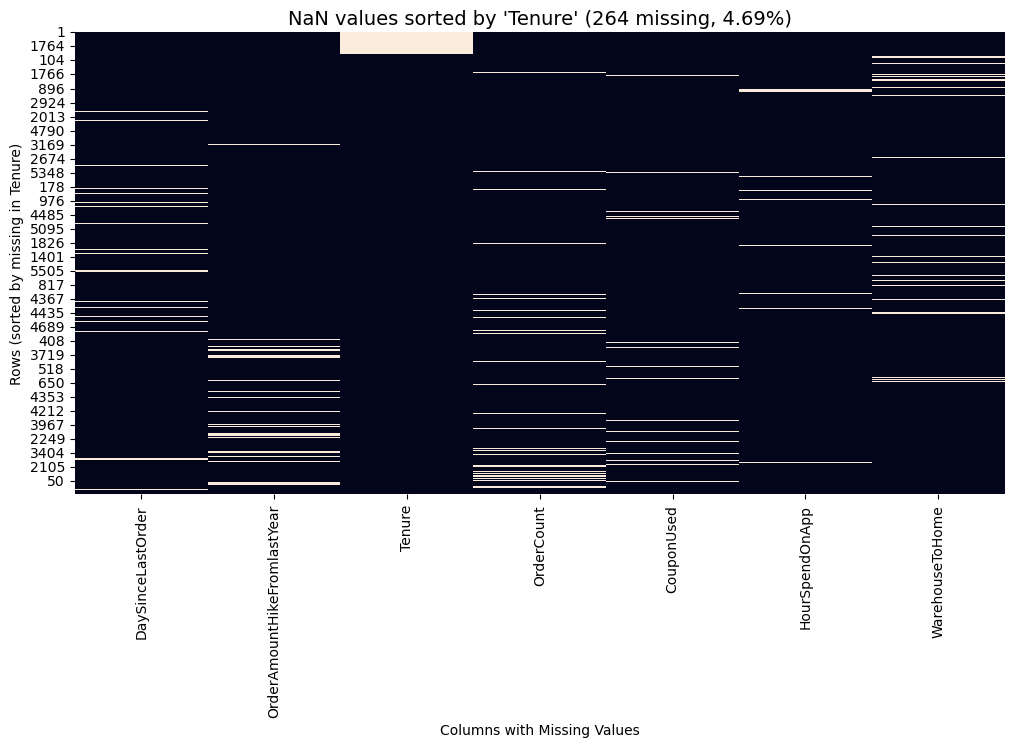

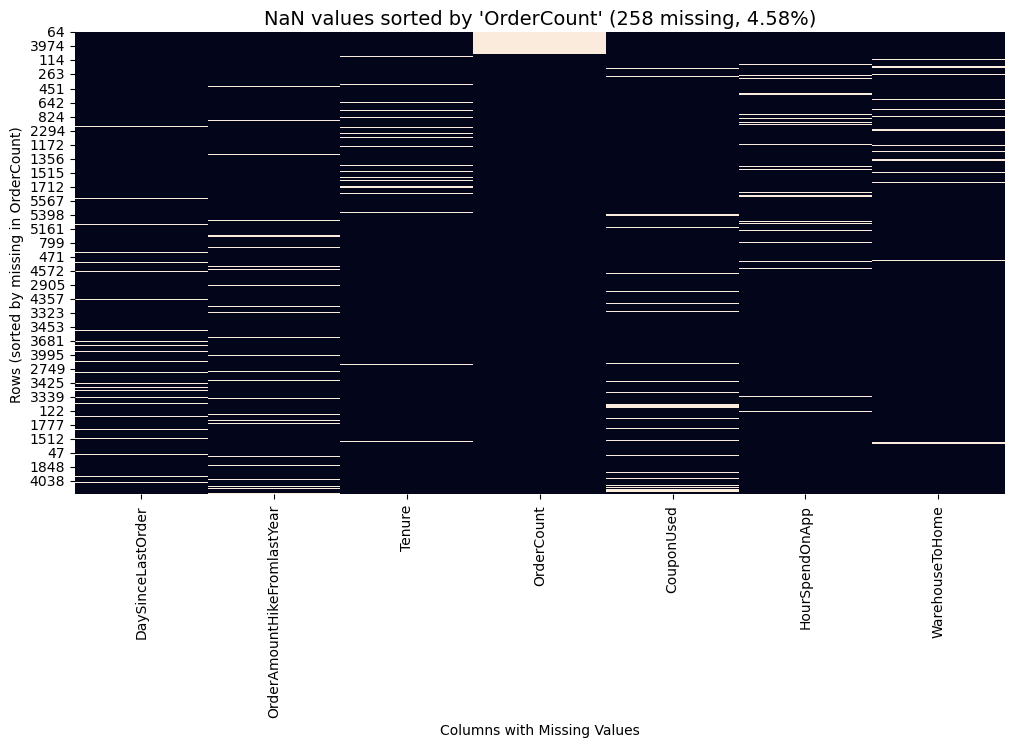

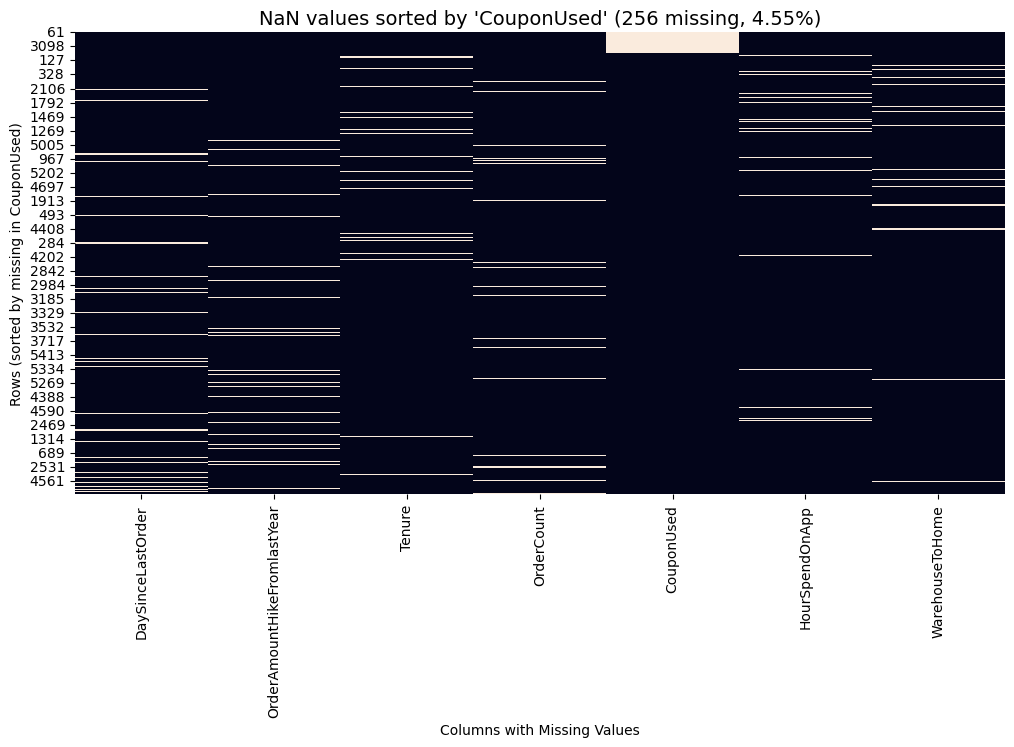

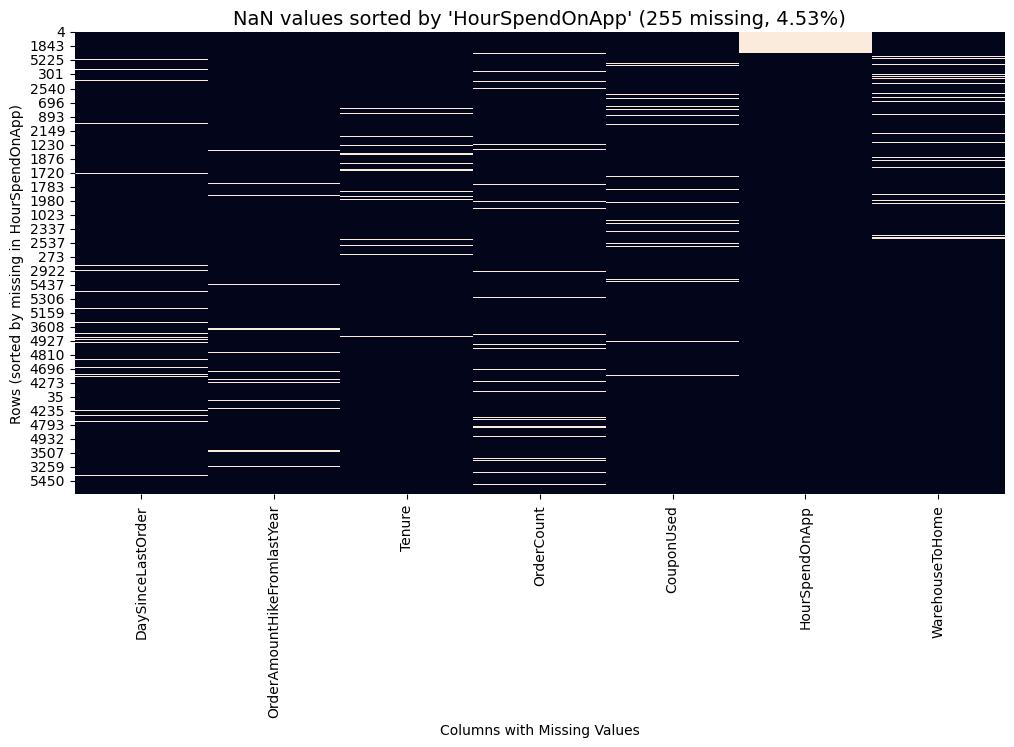

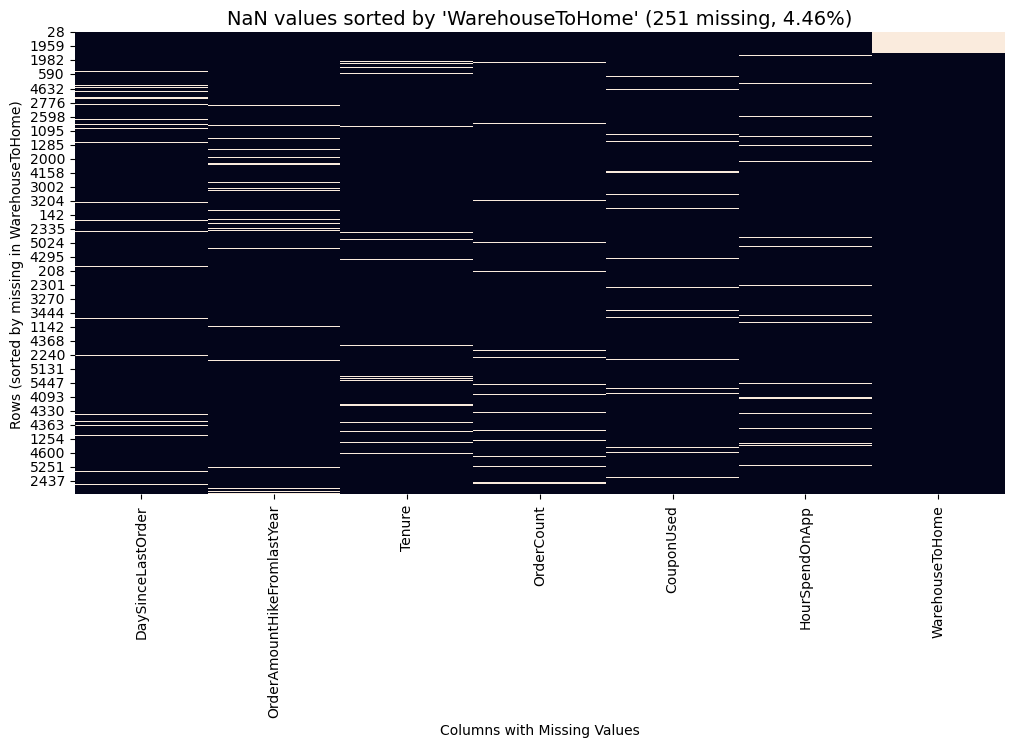

In [26]:
if len(columns_with_nan) > 0:
    nan_cols = columns_with_nan.index.to_list()

    for target_col in nan_cols:
        df_sorted = df.sort_values(
            by=target_col,
            na_position="first"
        )

        fig, ax = plt.subplots(figsize=(12, 6))
        sns.heatmap(
            df_sorted[nan_cols].isna(),
            cbar=False,
            ax=ax
        )

        total_missing = missing_df.at[target_col, "Total Missing"]
        pct_missing = missing_df.at[target_col, "Percentage (%)"]

        ax.set_title(
            f"NaN values sorted by '{target_col}' "
            f"({total_missing} missing, {pct_missing:.2f}%)",
            fontsize=14
        )
        ax.set_xlabel("Columns with Missing Values")
        ax.set_ylabel(f"Rows (sorted by missing in {target_col})")

        plt.show()

From the heatmap visualizations, the absence of data appears to be random across different features, with no discernible patterns or clusters. This suggests that the missing values are likely Missing Completely at Random (MCAR).

#### **Feature-wise Missing Value Handling Strategies**

##### **Tenure**

In [27]:
df[df["Tenure"].isna() == True]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
6,50007,1,NaN,Phone,3,11.0,COD,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Phone,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Phone,3,Single,2,0,12.0,1.0,1.0,1.0,122.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2756,52757,0,NaN,Phone,2,8.0,UPI,Female,2.0,3,Phone,4,Married,5,0,14.0,0.0,1.0,2.0,121.87
2760,52761,0,NaN,Computer,1,7.0,CC,Male,2.0,4,Phone,3,Married,2,0,12.0,0.0,1.0,0.0,120.08
2773,52774,0,NaN,Phone,3,7.0,CC,Male,3.0,4,Phone,4,Married,1,0,14.0,2.0,2.0,2.0,122.69
2783,52784,1,NaN,Computer,3,15.0,E wallet,Male,2.0,3,Phone,5,Married,2,0,19.0,1.0,1.0,0.0,117.90


Every row has customerID = database contains user that has signed up to the site. Missing tenure value most likely means tenure under a month or = 0.

##### **WarehouseToHome**

In [28]:
df[df["WarehouseToHome"].isna() == True]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
28,50029,0,18.0,Phone,1,NaN,Debit Card,Male,2.0,3,Laptop & Accessory,4,Married,9,0,18.0,1.0,1.0,15.0,123.48
35,50036,0,0.0,Phone,1,NaN,CC,Male,3.0,3,Phone,2,Divorced,2,0,24.0,0.0,2.0,2.0,123.23
39,50040,0,0.0,Computer,1,NaN,CC,Male,3.0,4,Phone,3,Married,2,1,15.0,0.0,1.0,1.0,125.66
41,50042,0,14.0,Phone,1,NaN,Debit Card,Male,2.0,3,Phone,3,Married,5,0,12.0,1.0,1.0,8.0,124.51
46,50047,1,0.0,Computer,3,NaN,COD,Female,3.0,5,Phone,5,Single,1,0,21.0,1.0,1.0,0.0,123.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2780,52781,0,17.0,Phone,1,NaN,CC,Male,2.0,3,Phone,1,Single,7,1,12.0,1.0,1.0,2.0,124.36
2781,52782,0,0.0,Phone,3,NaN,CC,Male,2.0,3,Phone,5,Single,2,1,11.0,1.0,1.0,2.0,123.80
2789,52790,1,19.0,Phone,1,NaN,COD,Male,3.0,3,Phone,3,Married,9,0,11.0,6.0,9.0,8.0,123.39
2794,52795,0,5.0,Phone,1,NaN,COD,Male,3.0,3,Phone,5,Single,2,0,14.0,0.0,1.0,2.0,124.39


No logical correlation with other features. No possible way to impute or replace the missing value. We will drop these rows later.

##### **HourSpendOnApp**

In [29]:
df[df["HourSpendOnApp"].isna() == True]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Phone,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
16,50017,1,0.0,Computer,1,12.0,Debit Card,Female,NaN,4,Phone,2,Single,2,1,18.0,1.0,1.0,0.0,129.26
37,50038,0,1.0,Phone,1,27.0,CC,Male,NaN,3,Phone,2,Divorced,2,0,11.0,0.0,1.0,2.0,127.13
44,50045,0,5.0,Phone,1,12.0,Debit Card,Male,NaN,3,Phone,3,Single,4,0,20.0,0.0,1.0,4.0,130.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2765,52766,0,14.0,Phone,1,7.0,Debit Card,Male,NaN,3,Phone,1,Married,4,0,22.0,0.0,1.0,0.0,127.82
2771,52772,0,5.0,Phone,1,35.0,Debit Card,Female,NaN,4,Phone,4,Single,2,0,13.0,0.0,4.0,1.0,128.37
2800,52801,0,13.0,Phone,1,8.0,Debit Card,Male,NaN,4,Phone,3,Single,3,0,14.0,0.0,2.0,2.0,128.09
2803,52804,0,8.0,Phone,1,7.0,Debit Card,Female,NaN,5,Phone,1,Married,2,0,12.0,1.0,1.0,1.0,129.77


In [30]:
df["HourSpendOnApp"].unique()

array([ 3.,  2., nan,  1.,  0.,  4.,  5.])

In [31]:
df[df["HourSpendOnApp"] == 0]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
150,50151,0,10.0,Computer,1,6.0,CC,Female,0.0,3,Fashion,2,Married,3,1,18.0,0.0,NaN,2.0,236.03
950,50951,0,5.0,Phone,1,16.0,CC,Male,0.0,3,Fashion,1,Single,3,0,25.0,0.0,1.0,NaN,212.44
1950,51951,0,11.0,Computer,1,18.0,Debit Card,Male,0.0,4,Laptop & Accessory,5,Married,3,0,15.0,1.0,1.0,2.0,162.88


Feature represents a "rating", not actual hours. Only 3 rows have this at 0. Most likely an error in data collection where NaN is supposed to be 0. We will replace NaN with 0 later.

##### **OrderAmountHikeFromlastYear**

In [32]:
df[df["OrderAmountHikeFromlastYear"].isna() == True]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
10,50011,1,4.0,Phone,1,18.0,COD,Female,2.0,3,Others,3,Divorced,2,0,NaN,9.0,15.0,8.0,295.45
40,50041,0,23.0,Phone,1,17.0,Debit Card,Female,2.0,3,Others,4,Single,4,0,NaN,2.0,4.0,4.0,299.26
65,50066,0,25.0,Phone,1,6.0,Debit Card,Male,3.0,4,Others,3,Divorced,1,0,NaN,1.0,11.0,9.0,299.99
106,50107,0,15.0,Phone,1,10.0,COD,Male,2.0,3,Others,2,Divorced,2,0,NaN,0.0,11.0,15.0,292.32
108,50109,0,23.0,Phone,3,6.0,CC,Female,3.0,3,Others,2,Married,4,0,NaN,1.0,1.0,6.0,295.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5534,55535,0,61.0,Phone,3,28.0,Debit Card,Female,4.0,4,Grocery,1,Married,6,1,NaN,1.0,2.0,1.0,303.75
5537,55538,0,23.0,Computer,1,9.0,Debit Card,Male,3.0,4,Others,1,Married,5,0,NaN,5.0,5.0,4.0,316.61
5561,55562,0,29.0,Phone,2,33.0,UPI,Male,4.0,2,Others,4,Married,6,1,NaN,2.0,2.0,5.0,321.36
5597,55598,0,13.0,Computer,1,16.0,Debit Card,Male,3.0,4,Others,1,Single,4,0,NaN,2.0,2.0,4.0,319.31


This feature have no negative value and only ranges from 11-26. Pretty safe to assume that this feature was winsorized. No logical way to replace with a reliable value. We will remove these rows later.

##### **CouponUsed**

In [33]:
df[df["CouponUsed"].isna() == True]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
61,50062,0,13.0,Phone,1,10.0,CC,Female,2.0,3,Others,3,Divorced,2,0,14.0,NaN,9.0,9.0,290.33
62,50063,0,28.0,Phone,1,20.0,CC,Male,3.0,2,Others,4,Single,9,0,11.0,NaN,2.0,15.0,287.22
69,50070,0,18.0,Computer,1,8.0,CC,Male,3.0,4,Grocery,2,Divorced,10,0,23.0,NaN,11.0,8.0,267.92
112,50113,0,25.0,Computer,3,8.0,Debit Card,Male,3.0,4,Others,3,Single,2,1,18.0,NaN,15.0,12.0,290.68
138,50139,0,19.0,Phone,3,8.0,COD,Female,3.0,5,Grocery,4,Divorced,4,1,12.0,NaN,7.0,7.0,268.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5354,55355,0,21.0,Phone,3,9.0,Debit Card,Female,3.0,2,Grocery,4,Married,8,0,15.0,NaN,2.0,3.0,284.72
5355,55356,0,23.0,Phone,1,8.0,Debit Card,Male,3.0,4,Grocery,3,Single,6,0,15.0,NaN,2.0,1.0,278.79
5461,55462,0,31.0,Computer,3,9.0,CC,Male,3.0,4,Grocery,4,Married,6,0,23.0,NaN,15.0,15.0,287.91
5470,55471,0,31.0,Computer,1,22.0,Debit Card,Male,3.0,4,Grocery,3,Married,4,1,15.0,NaN,3.0,3.0,282.87


NaN CouponUsed can be seen correlated with high CashbackAmount (> 250). However, not enough logical reasoning can be found to replace these values. We will drop these rows.

##### **OrderCount**

In [34]:
df[df["OrderCount"].isna() == True]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
64,50065,0,24.0,Phone,1,9.0,CC,Female,3.0,3,Grocery,4,Single,4,0,18.0,0.0,NaN,0.0,237.34
90,50091,0,14.0,Phone,3,12.0,Debit Card,Female,3.0,3,Fashion,2,Single,4,1,18.0,0.0,NaN,0.0,235.91
110,50111,0,16.0,Phone,3,22.0,E wallet,Female,3.0,3,Grocery,2,Divorced,6,1,22.0,0.0,NaN,9.0,260.64
120,50121,0,4.0,Computer,1,9.0,CC,Male,3.0,3,Fashion,3,Married,10,0,12.0,1.0,NaN,2.0,236.75
143,50144,0,18.0,Phone,1,26.0,CC,Male,3.0,3,Grocery,2,Divorced,1,1,14.0,0.0,NaN,10.0,234.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5565,55566,0,5.0,Computer,1,17.0,CC,Female,3.0,4,Fashion,3,Married,6,0,21.0,4.0,NaN,9.0,235.31
5581,55582,0,21.0,Computer,1,8.0,CC,Female,4.0,4,Fashion,4,Married,2,0,19.0,1.0,NaN,13.0,244.57
5590,55591,0,12.0,Phone,1,17.0,CC,Female,4.0,6,Fashion,3,Married,5,0,13.0,1.0,NaN,12.0,257.06
5621,55622,1,14.0,Phone,3,35.0,E wallet,Male,3.0,5,Fashion,5,Married,6,1,14.0,3.0,NaN,1.0,233.54


NaN OrderCount most likely represents 0, but this is conflicted with DaySinceLast order. Since data captures monthly insights, 0 OrderCount is impossible if DaySinceLastOrder < 30 or 31.

##### **DaySinceLastOrder**

In [35]:
df[df["DaySinceLastOrder"].isna() == True] 

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
88,50089,0,24.0,Phone,1,14.0,Debit Card,Male,2.0,4,Fashion,4,Divorced,6,0,16.0,1.0,4.0,NaN,224.90
97,50098,0,10.0,Computer,1,17.0,UPI,Male,2.0,3,Fashion,2,Married,2,1,14.0,0.0,1.0,NaN,221.85
126,50127,0,12.0,Computer,1,8.0,COD,Female,3.0,3,Fashion,3,Single,1,0,25.0,10.0,11.0,NaN,209.38
146,50147,1,10.0,Computer,1,35.0,Debit Card,Male,2.0,3,Fashion,4,Divorced,2,1,12.0,5.0,9.0,NaN,218.49
151,50152,0,2.0,Phone,1,28.0,Debit Card,Female,3.0,2,Fashion,4,Married,8,0,18.0,5.0,6.0,NaN,219.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5591,55592,0,6.0,Phone,3,8.0,E wallet,Female,3.0,4,Fashion,1,Married,3,0,20.0,1.0,6.0,NaN,229.22
5608,55609,0,15.0,Phone,3,10.0,Debit Card,Male,3.0,5,Laptop & Accessory,4,Married,4,0,12.0,2.0,2.0,NaN,214.38
5610,55611,0,9.0,Phone,2,33.0,Debit Card,Female,3.0,4,Fashion,1,Single,3,1,17.0,2.0,2.0,NaN,213.37
5623,55624,0,5.0,Computer,1,12.0,CC,Male,4.0,4,Laptop & Accessory,5,Single,2,0,20.0,2.0,2.0,NaN,224.36


Possibly means NaN = 0, but not enough evidence. We will remove these rows. NaN DaySinceLastOrder can also be seen correlated with a specific range of CashbackAmount (> 200 but < 250). 

#### **Summary**
- Tenure = Replace with 0
- WarehouseToHome = Remove
- HourSpendOnApp = Replace with 0
- OrderAmountHikeFromLastYear = Remove
- CouponUsed = Remove
- OrderCount = If DaysSinceLastOrder < 30, remove. Else, replace with 0.
- DaySinceLastOrder = Remove

These handling strategies are applied solely for analytical clarity, not for model training.

In [36]:
df["Tenure"].fillna(0, inplace=True)
df["HourSpendOnApp"].fillna(0, inplace=True)

df.dropna(subset=["WarehouseToHome"], inplace=True)
df.dropna(subset=["OrderAmountHikeFromlastYear"], inplace=True)
df.dropna(subset=["CouponUsed"], inplace=True)
df.dropna(subset=["DaySinceLastOrder"], inplace=True)
df.dropna(subset=["OrderCount"], inplace=True)

In [37]:
df.isna().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [38]:
df.to_csv('data_cleaned.csv', index=False)

## **3. Exploratory Data Analysis**

In [39]:
TableReport(df)

Processing column  20 / 20


,,,,,,,,,,,,,,,,,,,,


In [40]:
def iqr_outlier_summary(df, cols):
    results = []

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

        results.append({
            "feature": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_pct": outlier_count / len(df)
        })

    return pd.DataFrame(results)

In [41]:
numeric_cols = ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
outlier_summary = iqr_outlier_summary(df, numeric_cols)
outlier_summary.sort_values("outlier_pct", ascending=False, ignore_index=True)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
0,OrderCount,1.00,3.00,2.00,-2.00,6.00,444,0.103424
1,CouponUsed,1.00,2.00,1.00,-0.50,3.50,412,0.095970
2,NumberOfDeviceRegistered,3.00,4.00,1.00,1.50,5.50,307,0.071512
3,HourSpendOnApp,2.00,3.00,1.00,0.50,4.50,259,0.060331
4,NumberOfAddress,2.00,5.00,3.00,-2.50,9.50,211,0.049150
5,CashbackAmount,145.07,175.03,29.96,100.13,219.97,41,0.009550
6,DaySinceLastOrder,2.00,7.00,5.00,-5.50,14.50,25,0.005823
7,OrderAmountHikeFromlastYear,13.00,18.00,5.00,5.50,25.50,23,0.005358
8,Tenure,1.00,13.00,12.00,-17.00,31.00,2,0.000466
9,WarehouseToHome,9.00,20.00,11.00,-7.50,36.50,2,0.000466


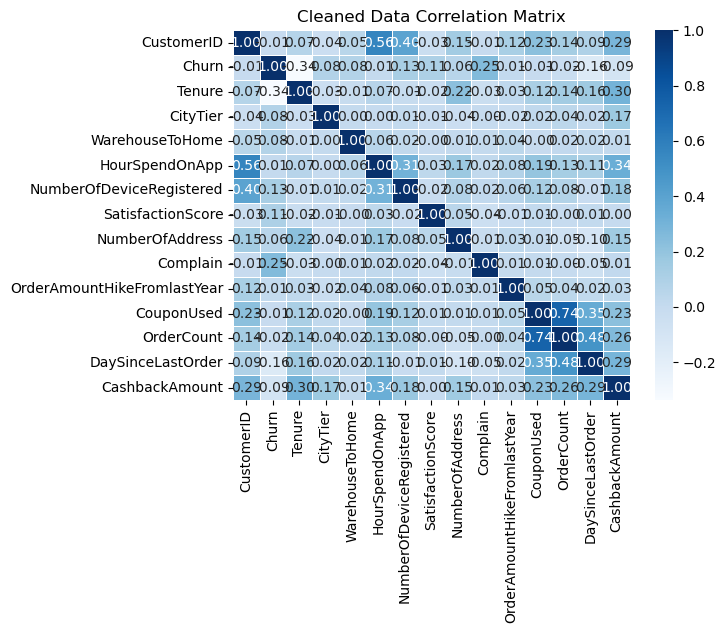

In [42]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5)
plt.title("Cleaned Data Correlation Matrix")
plt.show()

Complain is the most correlated with churn.

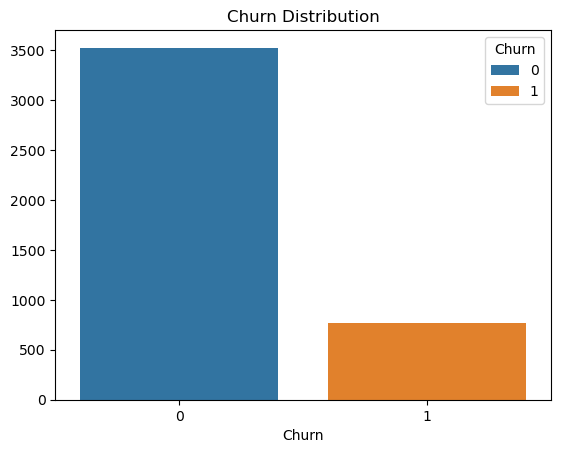

In [43]:
sns.countplot(data=df, x="Churn", hue="Churn")
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

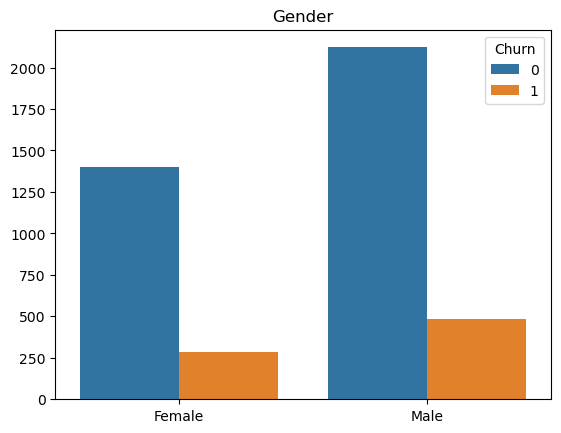

In [44]:
sns.countplot(data=df, x="Gender", hue="Churn")
plt.ylabel("")
plt.xlabel("")
plt.title("Gender")
plt.show()

Male seems to have better brand loyalty.

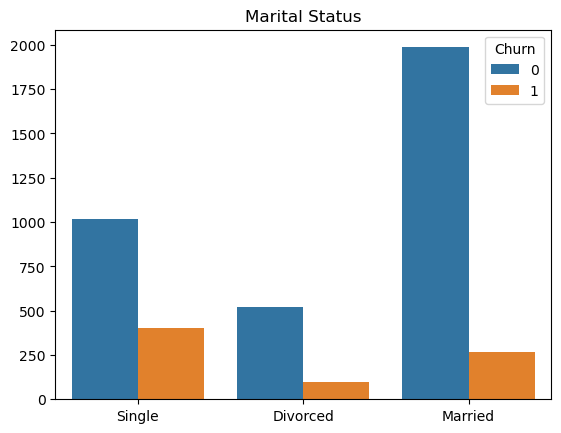

In [45]:
sns.countplot(data=df, x="MaritalStatus", hue="Churn")
plt.ylabel("")
plt.xlabel("")
plt.title("Marital Status")
plt.show()

Married users arer typically wealthier. They care less about getting a better deal and have better brand loyalty.

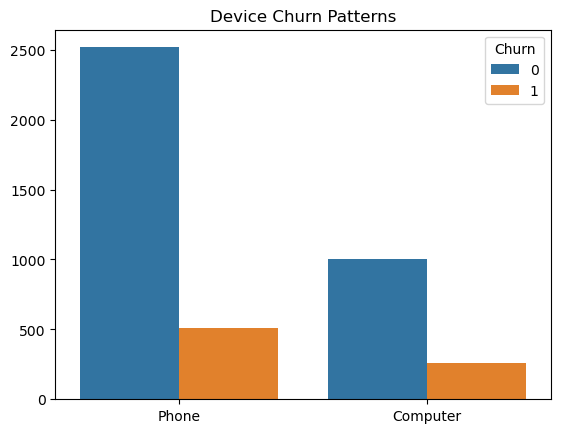

In [46]:
#Device Churn Plot
sns.countplot(data=df, x="PreferredLoginDevice", hue="Churn")
plt.ylabel("")
plt.xlabel("")
plt.title("Device Churn Patterns")
plt.show()

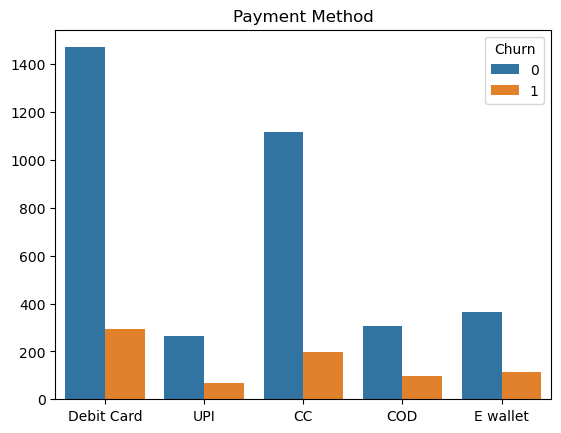

In [47]:
sns.countplot(data=df, x="PreferredPaymentMode", hue="Churn")
plt.ylabel("")
plt.xlabel("")
plt.title("Payment Method")
plt.show()

UPI, COD, and E-wallet has visibly the highest churn/not churn ratio. Users that prefer this payment method are value oriented shoppers that usually jump from store to store to get the best deals. This means they have the least amount of brand loyalty.

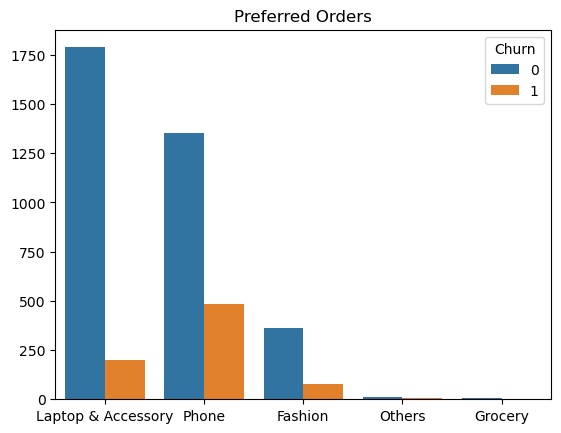

In [48]:
sns.countplot(data=df, x="PreferedOrderCat", hue="Churn")
plt.ylabel("")
plt.xlabel("")
plt.title("Preferred Orders")
plt.show()

Most users look to flopkart to purchase laptops, phones, accessories, and electronic devices.

Users that are in the market for a phone in flopkart are smart buyers that consider a lot of things before making their purchase, which is why they are more likely to churn and purchase their devices elsewhere.

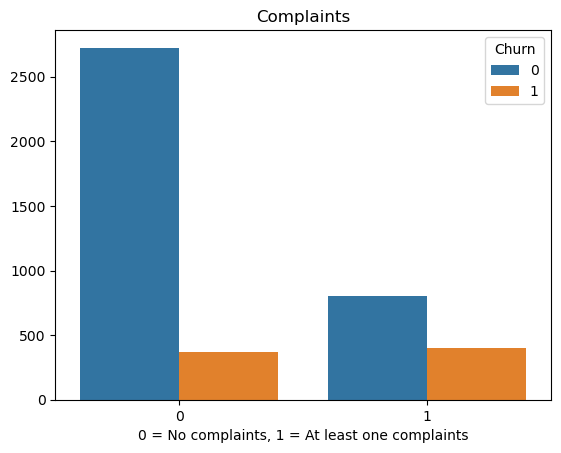

In [49]:
sns.countplot(data=df, x="Complain", hue="Churn")
plt.title("Complaints")
plt.ylabel("")
plt.xlabel("0 = No complaints, 1 = At least one complaints")
plt.show()

Users that have submitted a complaint are a lot more likely to churn.

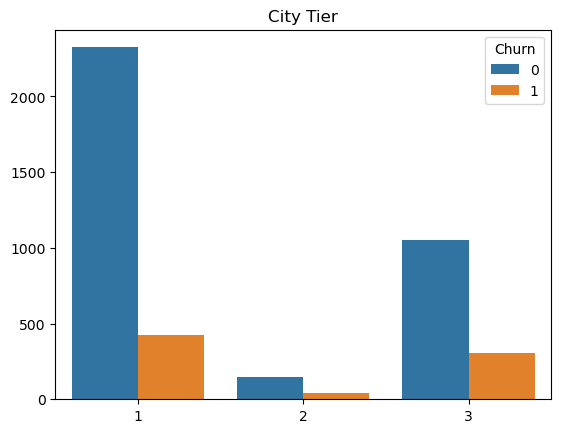

In [50]:
sns.countplot(data=df, x="CityTier", hue="Churn")
plt.title("City Tier")
plt.ylabel("")
plt.xlabel("")
plt.show()

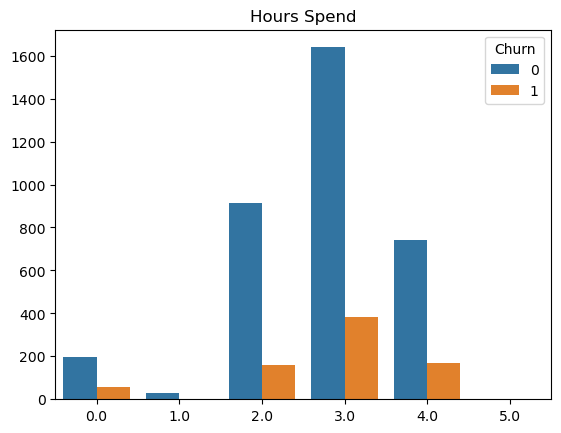

In [51]:
sns.countplot(data=df, x="HourSpendOnApp", hue="Churn")
plt.title("Hours Spend")
plt.ylabel("")
plt.xlabel("")
plt.show()

Ratio seems to be the highest at 0 and 4. Showing trends that customers that spend very little or a lot of time on the app are more likely to churn.

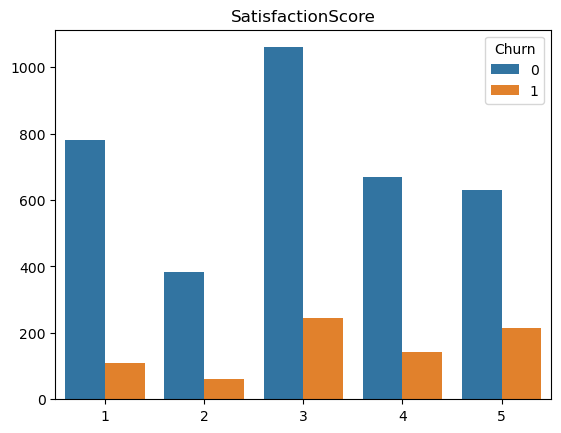

In [52]:
sns.countplot(data=df, x="SatisfactionScore", hue="Churn")
plt.title("SatisfactionScore")
plt.ylabel("")
plt.xlabel("")
plt.show()

Interesting trend where users that are the most satisfied are more likely to churn than others.

In [53]:
def numerical_columns_analysis(df,col):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    sns.boxplot(df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

### **3.1 Numerical Column Analysis**

#### 1. Tenure

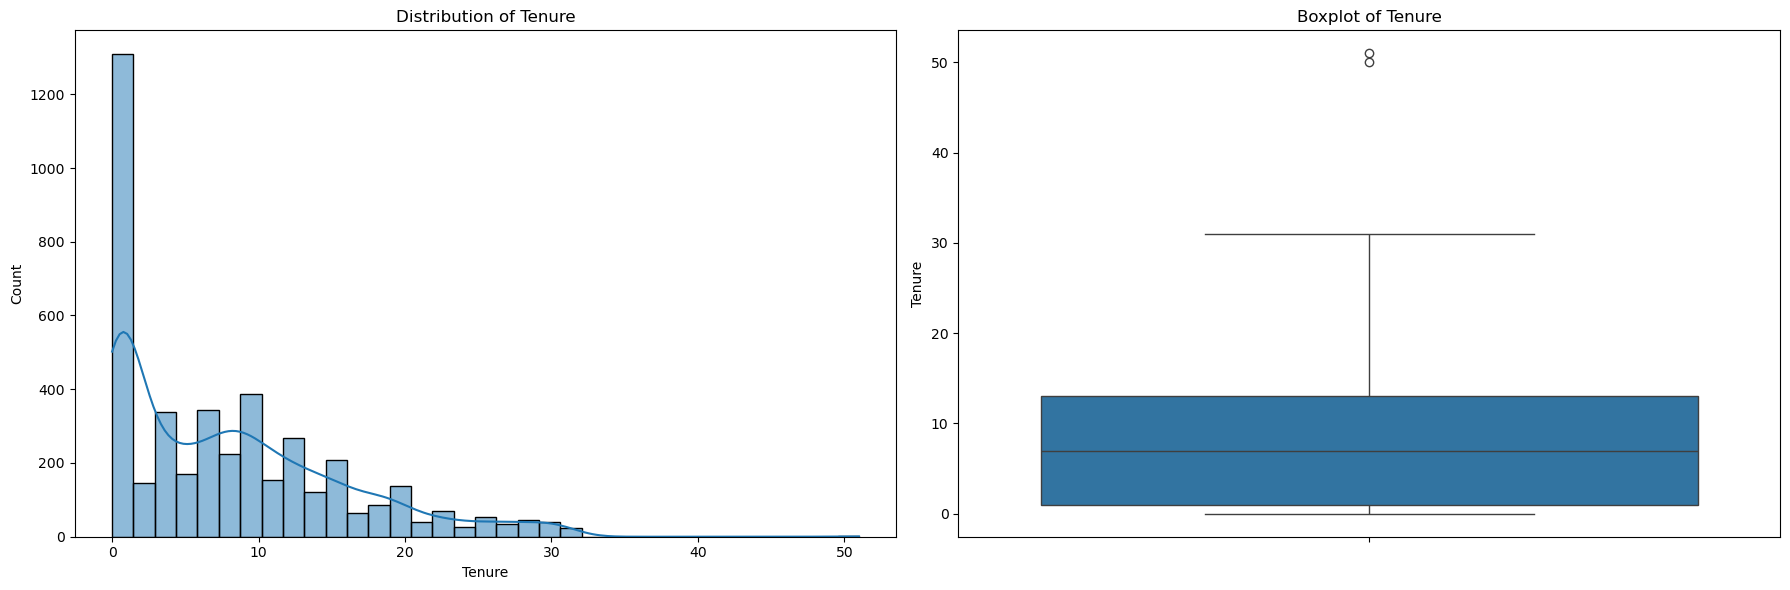

In [54]:
numerical_columns_analysis(df, 'Tenure')

Most users have a very short tenure, while very few outliers can be seen with a very long tenure.

#### 2. HourSpendOnApp

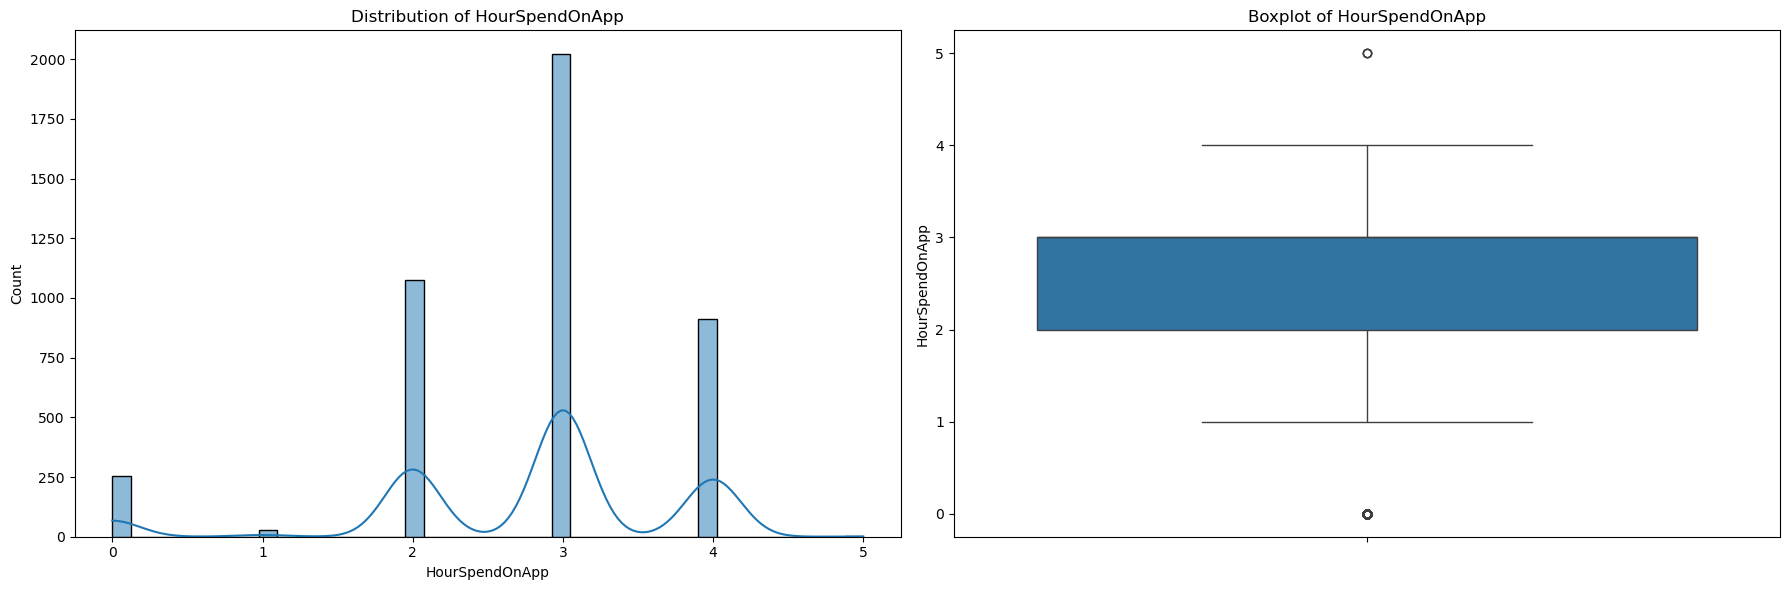

In [55]:
numerical_columns_analysis(df, 'HourSpendOnApp')

The average user is decently engaged with the app, rating 3 out of 5 in the scale, with a few users spending really low and high hours on the app.

#### 3. NumberOfDeviceRegistered

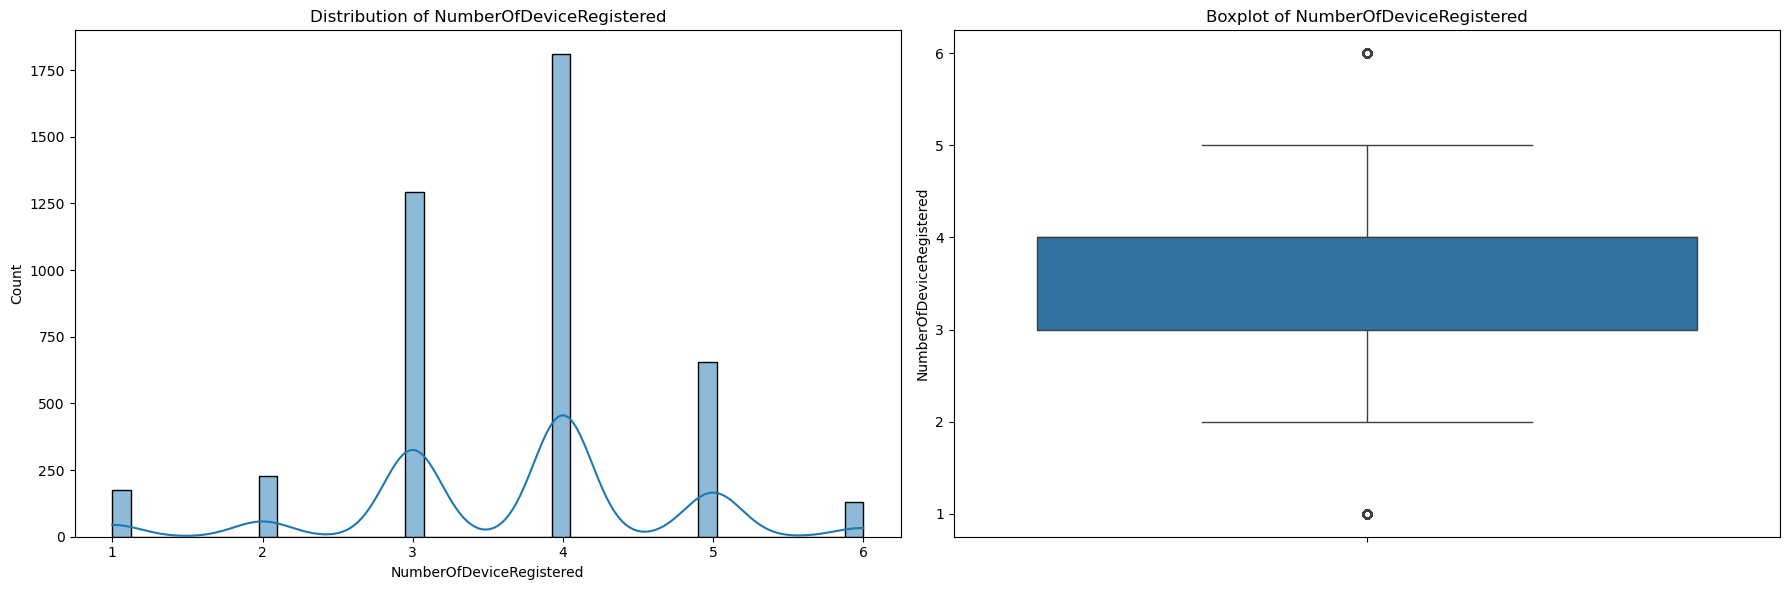

In [56]:
numerical_columns_analysis(df, 'NumberOfDeviceRegistered')

The average user has 4 devices registered, showing a very tech-aware market. Some outliers only have 1 or 6 amount of devices registered.

#### 3. NumberOfAddress

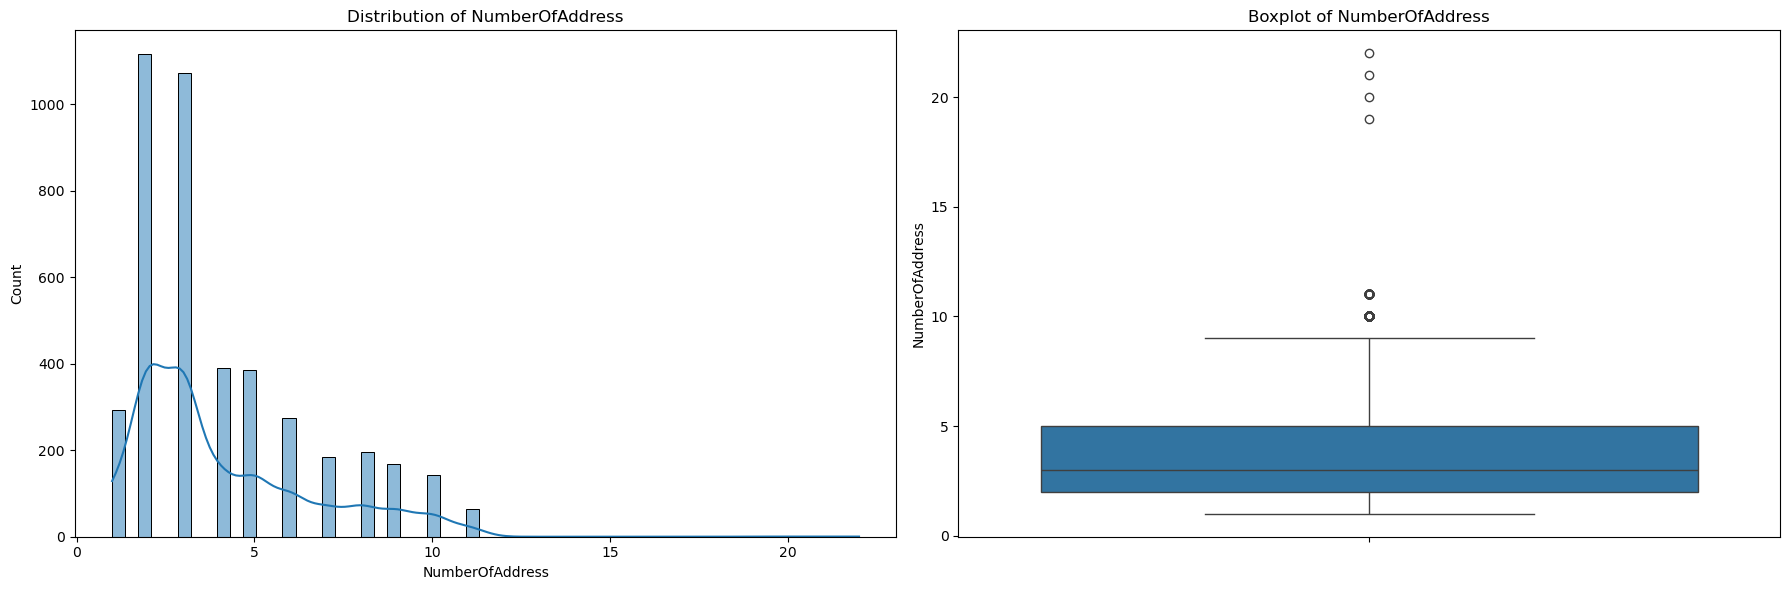

In [57]:
numerical_columns_analysis(df, 'NumberOfAddress')

The average user has < 5 registered addresses with some outliers having significantly more.

#### 4. OrderAmountHikeFromlastYear

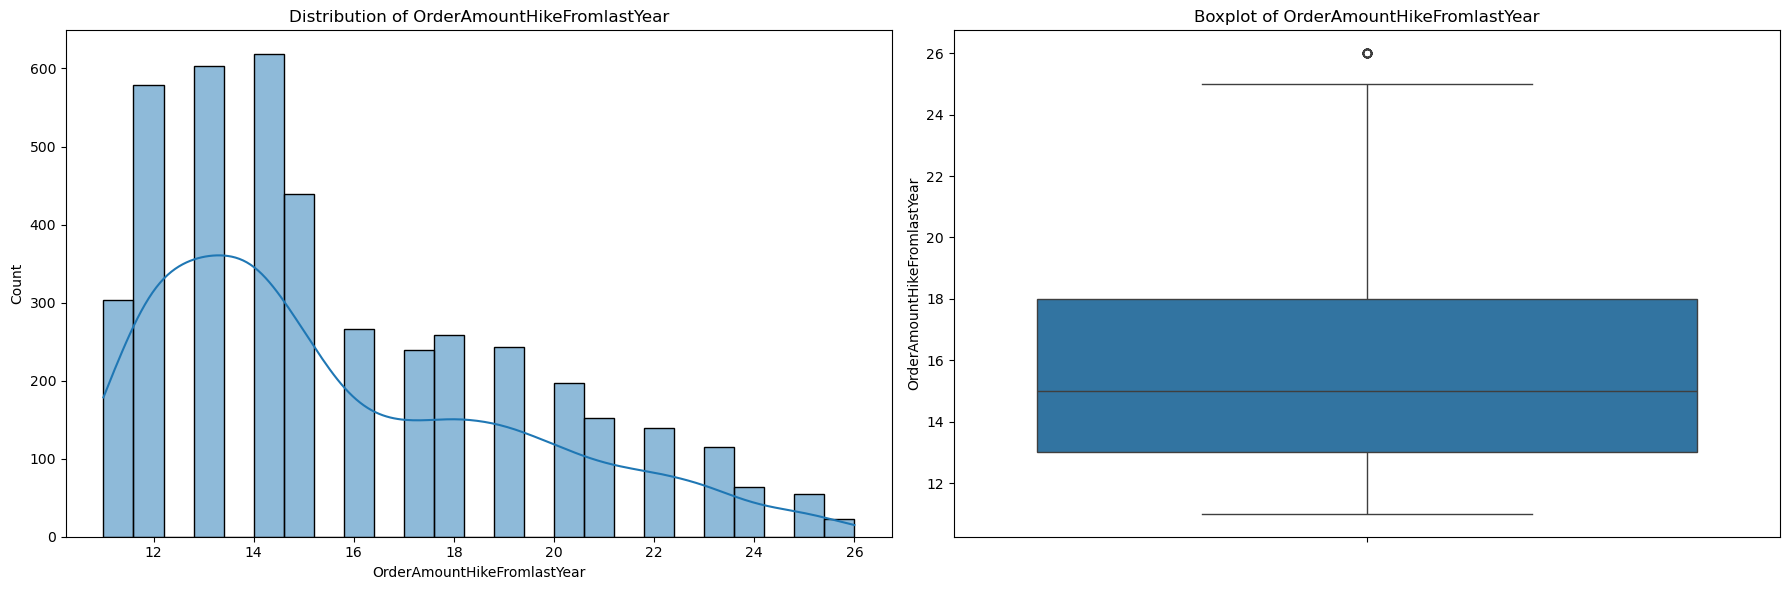

In [58]:
numerical_columns_analysis(df, 'OrderAmountHikeFromlastYear')

The average customer have an order amount hike of 12 to 16. This means that the company is generally doing a good job of maintaining and improving sales. Though this is not entirely reliable since we have determined that the data is most likely winsorized to not include customers with Negative order hike amount.

#### 5. CouponUsed

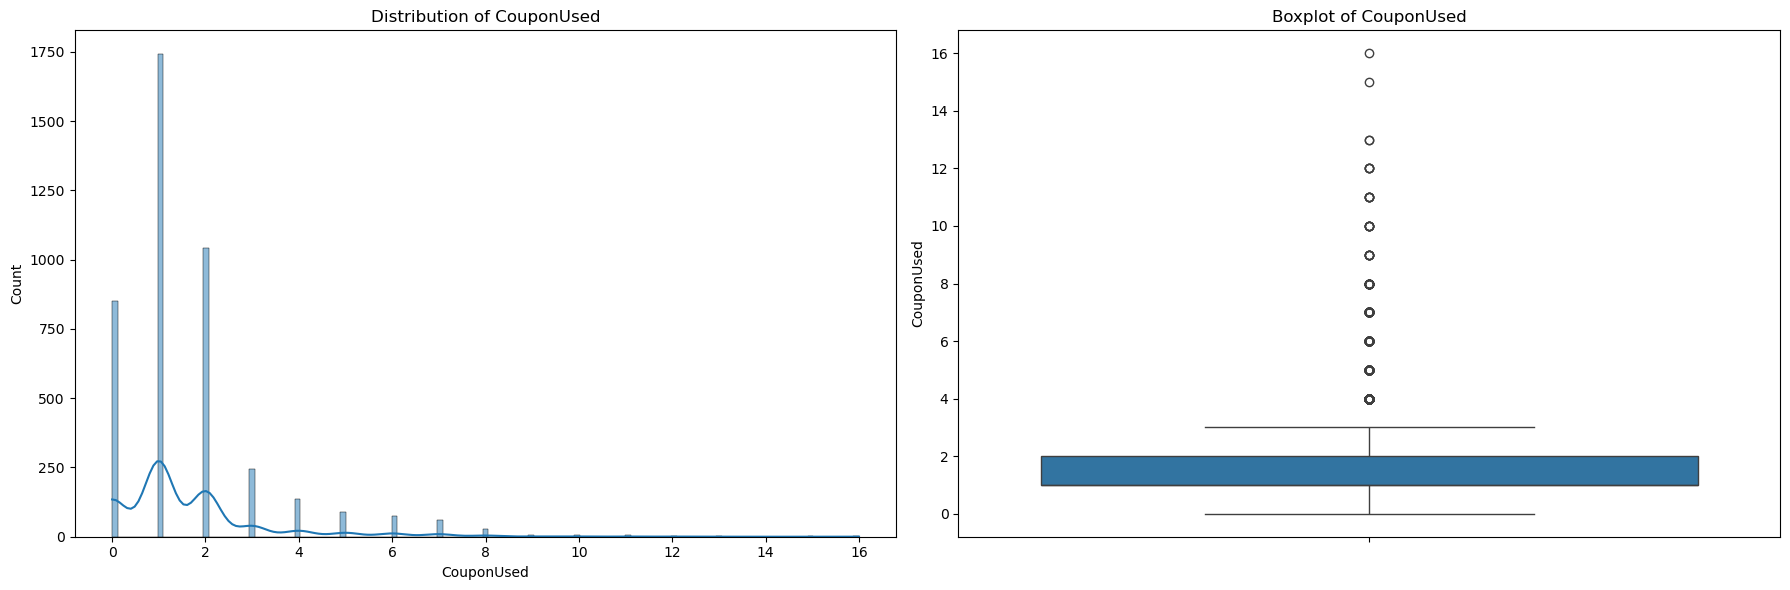

In [59]:
numerical_columns_analysis(df, 'CouponUsed')

Most users rarely use coupons throughout their transactions that month. Could be an actionable insight to provide more coupons and discounts to improve retention.

#### 6. OrderCount

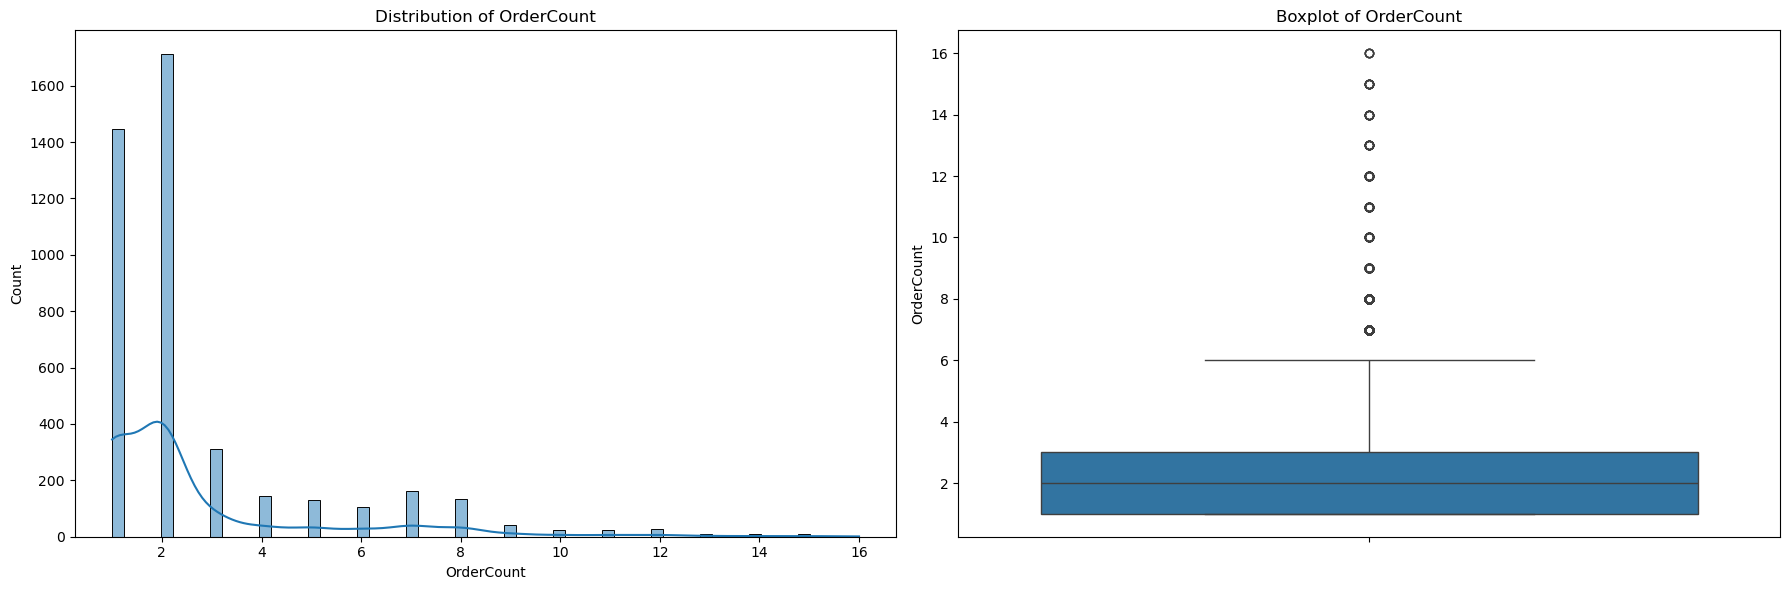

In [60]:
numerical_columns_analysis(df, 'OrderCount')

The common user only completes 2 orders in a month.

#### 7. DaySinceLastOrder

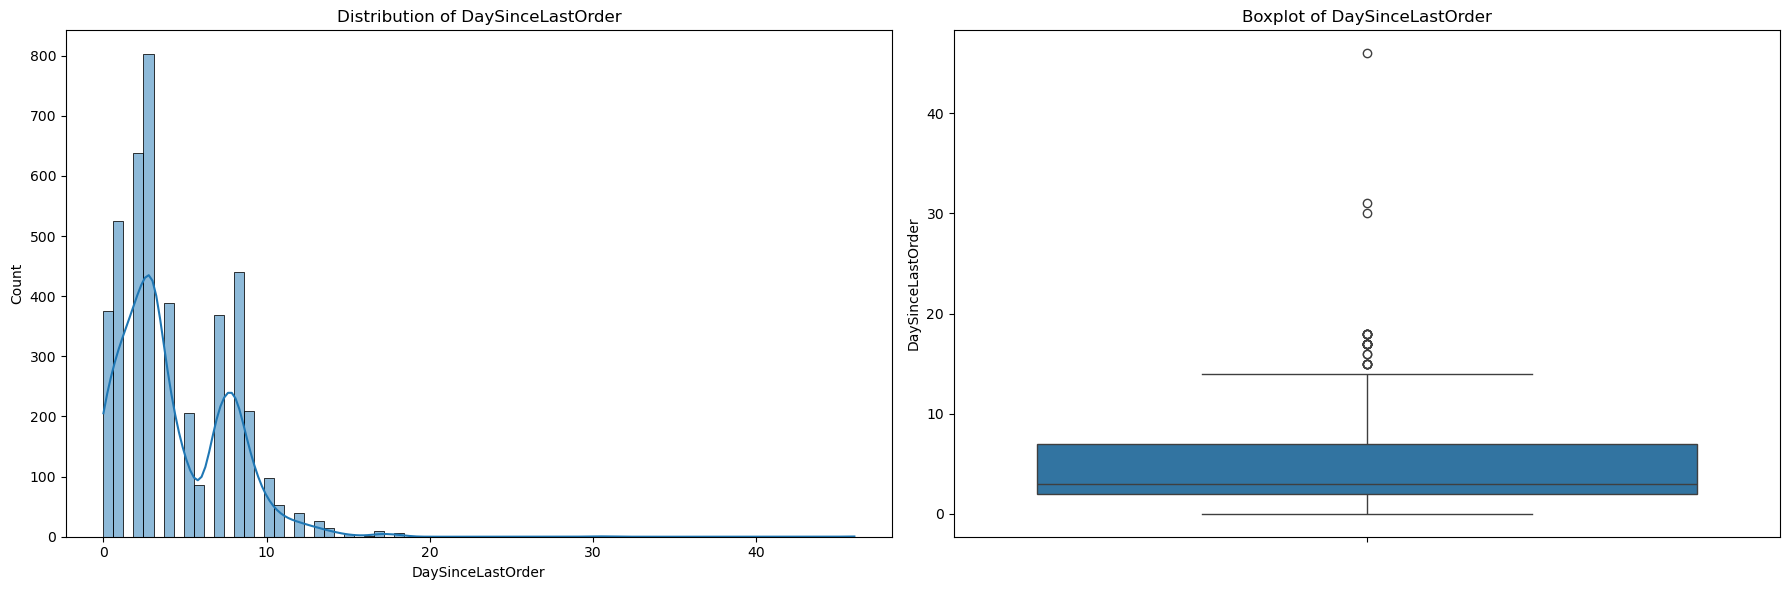

In [61]:
numerical_columns_analysis(df, 'DaySinceLastOrder')

Since the day of data collection, the majority of users have placed an order recently with some outliers who havent placed any order in more than a month.

#### 8. CashbackAmount

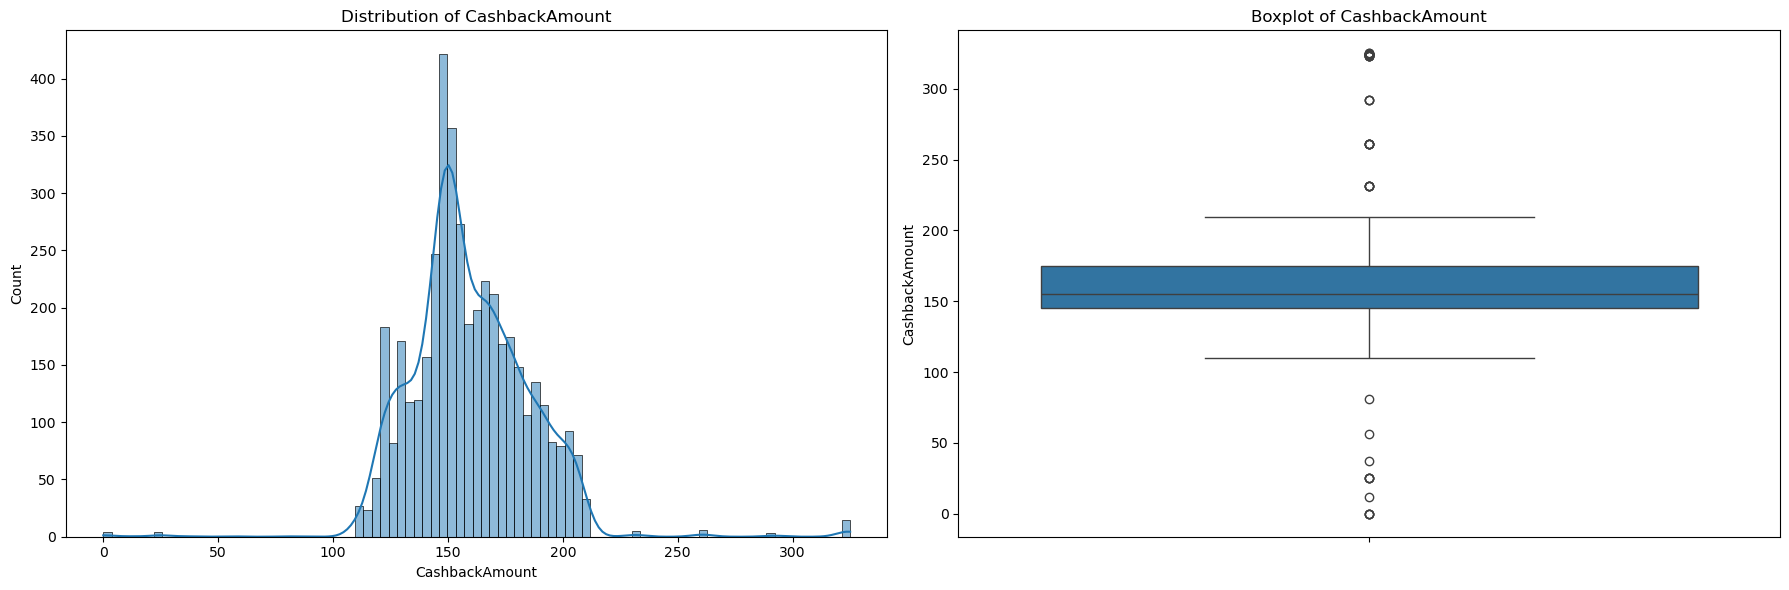

In [62]:
numerical_columns_analysis(df, 'CashbackAmount')

The average user receives around USD 150 in cashback amounts, and a decent amount receiving more than USD 200 and 250. CashbackAmount can be an indicator of amount spent in that month by each customer though further analysis is required.

### **3.2 Bivariate Analysis of Numerical Columns by Churn**

- Numbers explain "How much is the difference?"
- Boxplot explain "How they are different?" 
- Statistical tests explain "Are the differences statistically significant?"

In [63]:
def numerical_bivariate_analysis(df, col, target='Churn'):
 
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    sns.boxplot(x=target, y=col, data=df, hue=target, legend=False)
    ax.set_title(f'{col} by {target}')
    plt.show()

#### **1. Tenure**

In [64]:
df.groupby('Churn')['Tenure'].agg(['median', 'mean', 'count'])

,median,mean,count
Churn,,,
0,8.0,9.274766,3523
1,1.0,2.522078,770


Churned customers have a substantially shorter tenure compared to non-churned customers. The median tenure of churned customers is 1 month, while non-churned customers have a median tenure of 8 months.

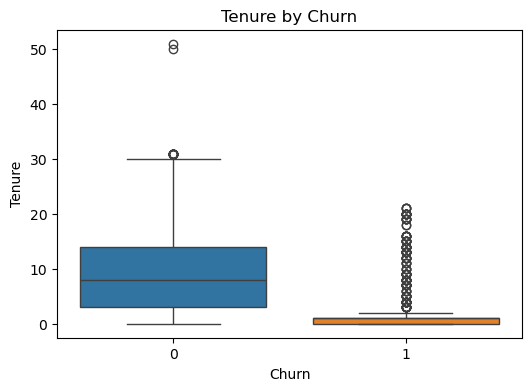

In [65]:
numerical_bivariate_analysis(df, 'Tenure', target='Churn')

The boxplot confirms that churned customers have shorter tenure, with the majority of observations concentrated at low values, while non-churned customers show a broader tenure distribution and higher central tendency. This shows a trend that users have a **window of tenure** where they are more at-risk of churning.

In [66]:
from scipy.stats import mannwhitneyu

churned = df[df['Churn'] == 1]['Tenure'].dropna()
non_churned = df[df['Churn'] == 0]['Tenure'].dropna()

stat, p = mannwhitneyu(churned, non_churned, alternative='two-sided')
p

np.float64(5.378312768070452e-150)

P-value < 0.001 : There is a statistically significant difference in tenure between churned and non-churned customers, combined with the large median gap and clear distributional separation indicates that **Tenure is a strong behavioral indicator of churn.**

#### **2. OrderCount**

In [67]:
df.groupby('Churn')['OrderCount'].agg(['median', 'mean', 'count'])

,median,mean,count
Churn,,,
0,2.0,2.708771,3523
1,2.0,2.579221,770


Bivariate analysis indicates that the median order count is identical for churned and non-churned customers, suggesting that total historical order volume alone does not clearly differentiate churn behavior.

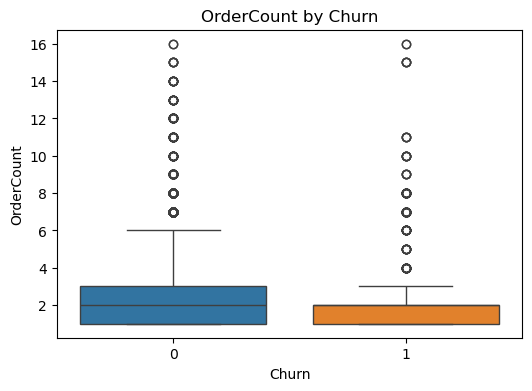

In [68]:
numerical_bivariate_analysis(df, 'OrderCount', target='Churn')

The boxplot shows slightly similar distributions for both churned and non-churned customers, indicating no substantial difference in order counts between the two groups.

In [69]:
churned = df[df['Churn'] == 1]['OrderCount'].dropna()
non_churned = df[df['Churn'] == 0]['OrderCount'].dropna()

stat, p = mannwhitneyu(churned, non_churned, alternative='two-sided')
p

np.float64(0.6815696240266241)

P-value > 0.05 : There is no statistically significant difference in OrderCount between churned and non-churned customers, suggesting **OrderCount has limited value in differentiating churn behavior.**

#### **3. DaySinceLastOrder**

In [70]:
df.groupby('Churn')['DaySinceLastOrder'].agg(['median', 'mean', 'count'])

,median,mean,count
Churn,,,
0,3.0,4.513483,3523
1,2.0,3.138961,770


Churn customers have recent median days since last order of 2 days, while non-churn customers have a median of 3 days, indicating that recency alone does not clearly differentiate churn behavior in this dataset.

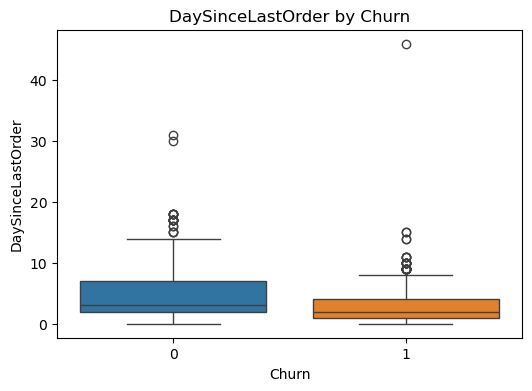

In [71]:
numerical_bivariate_analysis(df, 'DaySinceLastOrder', target='Churn')

The boxplot reveals substantial overlap in the distribution of days since last order between churned and non-churned customers, suggesting that this feature alone is not a strong discriminator of churn.

In [72]:
churned = df[df['Churn'] == 1]['DaySinceLastOrder'].dropna()
non_churned = df[df['Churn'] == 0]['DaySinceLastOrder'].dropna()
stat, p = mannwhitneyu(churned, non_churned, alternative='two-sided')
p

np.float64(1.1915115278278586e-33)

The difference in DaySinceLastOrder is statistically significant (p < 0.001), but the small median gap and overlapping distributions suggest that **DaySinceLastOrder has limited value in differentiating churn behavior.**

#### **4. HourSpendOnApp**

In [73]:
df.groupby('Churn')['HourSpendOnApp'].agg(['median', 'mean', 'count'])

,median,mean,count
Churn,,,
0,3.0,2.769515,3523
1,3.0,2.785714,770


Bivariate analysis indicates that the median hours spent on the app is identical for churned and non-churned customers, suggesting that hour spent on the app alone does not clearly differentiate churn behavior.

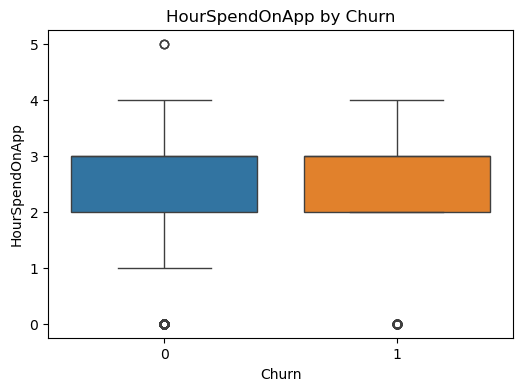

In [74]:
numerical_bivariate_analysis(df, 'HourSpendOnApp', target='Churn')

The boxplot shows a high degree of overlap in hours spent on the app between churned and non-churned customers, with similar medians and interquartile ranges, indicating limited discriminatory power.

In [75]:
churned = df[df['Churn'] == 1]['HourSpendOnApp'].dropna()
non_churned = df[df['Churn'] == 0]['HourSpendOnApp'].dropna()
stat, p = mannwhitneyu(churned, non_churned, alternative='two-sided')
p

np.float64(0.16706356112277565)

P-value > 0.05 : There is no statistically significant difference in HourSpendOnApp between churned and non-churned customers, suggesting **HourSpendOnApp has limited value in differentiating churn behavior.**

#### **5. CouponUsed**

In [76]:
df.groupby('Churn')['CouponUsed'].agg(['median', 'mean', 'count'])

,median,mean,count
Churn,,,
0,1.0,1.615952,3523
1,1.0,1.585714,770


Bivariate analysis indicates that the median coupon used is identical for churned and non-churned customers, suggesting that coupon usage alone does not clearly differentiate churn behavior.

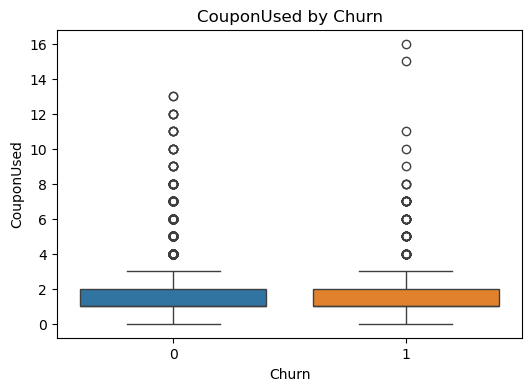

In [77]:
numerical_bivariate_analysis(df, 'CouponUsed', target='Churn')

The boxplot shows a high degree of overlap in hours spent on the app between churned and non-churned customers, with similar medians and interquartile ranges, indicating limited discriminatory power.

In [78]:
churned = df[df['Churn'] == 1]['CouponUsed'].dropna()
non_churned = df[df['Churn'] == 0]['CouponUsed'].dropna()
stat, p = mannwhitneyu(churned, non_churned, alternative='two-sided')
p

np.float64(0.6237801520122598)

P-value > 0.05 : There is no statistically significant difference in CouponUsed between churned and non-churned customers, suggesting **CouponUsed has limited value in differentiating churn behavior.**

#### **6. CashbackAmount**

In [79]:
df.groupby('Churn')['CashbackAmount'].agg(['median', 'mean', 'count'])

,median,mean,count
Churn,,,
0,157.31,160.540627,3523
1,149.41,154.250026,770


Bivariate analysis shows that non-churned customers have a slightly higher median cashback amount compared to churned customers. However, the difference in central tendency is relatively small (~5%).

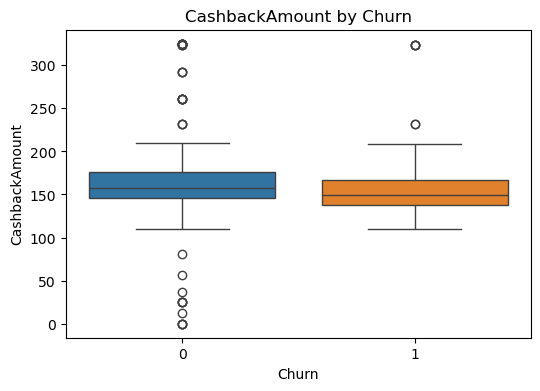

In [80]:
numerical_bivariate_analysis(df, 'CashbackAmount', target='Churn')

The boxplot reveals substantial overlap in cashback distributions between churned and non-churned customers, indicating limited separation based on cashback amount alone.

In [81]:
churned = df[df['Churn'] == 1]['CashbackAmount'].dropna()
non_churned = df[df['Churn'] == 0]['CashbackAmount'].dropna()
stat, p = mannwhitneyu(churned, non_churned, alternative='two-sided')
p

np.float64(4.1267249478743055e-15)

Although the Mann–Whitney U test indicates a statistically significant difference in CashbackAmount between churned and non-churned customers (p < 0.001), the small median gap and overlapping distributions suggest that **CashbackAmount has limited value in differentiating churn behavior**.

In [82]:
df.groupby('Churn')['WarehouseToHome'].agg(['median', 'mean', 'count'])

,median,mean,count
Churn,,,
0,13.0,15.289810,3523
1,15.0,17.024675,770


#### **7. WarehouseToHome**

In [83]:
df.groupby('Churn')['WarehouseToHome'].agg(['median', 'mean', 'count'])

,median,mean,count
Churn,,,
0,13.0,15.289810,3523
1,15.0,17.024675,770


Bivariate analysis shows that non-churned customers have a slightly higher median WarehouseToHome distance compared to churned customers. However, the difference in central tendency is relatively small (~2 km).

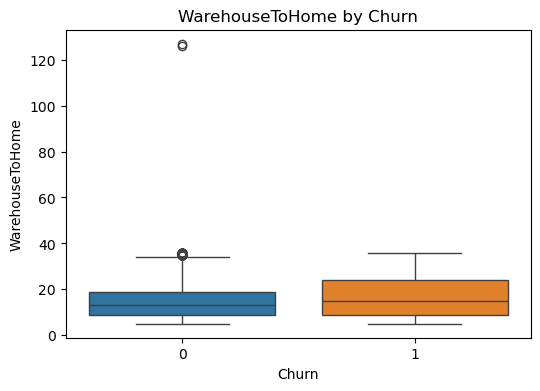

In [84]:
numerical_bivariate_analysis(df, 'WarehouseToHome', target='Churn')

The boxplot reveals substantial overlap in WarehouseToHome distributions between churned and non-churned customers, indicating limited separation based on this feature alone.

In [85]:
churned = df[df['Churn'] == 1]['CashbackAmount'].dropna()
non_churned = df[df['Churn'] == 0]['CashbackAmount'].dropna()
stat, p = mannwhitneyu(churned, non_churned, alternative='two-sided')
p

np.float64(4.1267249478743055e-15)

Although the Mann–Whitney U test indicates a statistically significant difference in WarehouseToHome between churned and non-churned customers (p < 0.001), the small median gap and overlapping distributions suggest that **WarehouseToHome has limited value in differentiating churn behavior**.

#### **Numerical Bivariate Analysis Summary**

In [86]:
core_features = [
    'Tenure',
    'OrderCount',
    'DaySinceLastOrder',
    'HourSpendOnApp',
    'CouponUsed',
    'CashbackAmount',
    'WarehouseToHome'
]

summary = []

for col in core_features:
    churned = df[df['Churn'] == 1][col].dropna()
    non_churned = df[df['Churn'] == 0][col].dropna()
    
    med_churn = churned.median()
    med_non = non_churned.median()
    
    stat, p = mannwhitneyu(churned, non_churned, alternative='two-sided')
    
    perc_diff = ((med_churn - med_non) / med_non) * 100
    
    summary.append({
        'Feature': col,
        'Median_NonChurn': med_non,
        'Median_Churn': med_churn,
        'Percentage_Diff (%)': perc_diff,
        'p_value': p
    })

summary_df = pd.DataFrame(summary)
interpretation_map = {
    'Tenure': 'Strong behavioral indicator',
    'OrderCount': 'Not differentiating',
    'DaySinceLastOrder': 'Has limited value in differentiating churn behavior',
    'HourSpendOnApp': 'Has limited value in differentiating churn behavior',
    'CouponUsed': 'Not differentiating',
    'CashbackAmount': 'Has limited value in differentiating churn behavior'
}

summary_df['Interpretation'] = summary_df['Feature'].map(interpretation_map)
summary_df

,Feature,Median_NonChurn,Median_Churn,Percentage_Diff (%),p_value,Interpretation
0,Tenure,8.00,1.00,-87.500000,5.378313e-150,Strong behavioral indicator
1,OrderCount,2.00,2.00,0.000000,6.815696e-01,Not differentiating
2,DaySinceLastOrder,3.00,2.00,-33.333333,1.191512e-33,Has limited value in differentiating churn behavior
3,HourSpendOnApp,3.00,3.00,0.000000,1.670636e-01,Has limited value in differentiating churn behavior
4,CouponUsed,1.00,1.00,0.000000,6.237802e-01,Not differentiating
5,CashbackAmount,157.31,149.41,-5.021931,4.126725e-15,Has limited value in differentiating churn behavior
6,WarehouseToHome,13.00,15.00,15.384615,7.119186e-08,NaN


The bivariate numerical analysis reveals that tenure is the most discriminative feature between churned and non-churned customers, showing a large median gap and strong statistical significance. 

Other numerical features exhibit either negligible median differences or limited practical separation, even when statistically significant. This indicates that churn behavior in the dataset is largely explained by customer lifecycle(Tenure) effects rather than transactional volume.

### **3.3 Categorical Bivariate Analysis**

Categorical bivariate analysis will be performed using Chi-Squared tests to evaluate the association between categorical features and customer churn. This analysis will help identify which categorical variables have a significant relationship with churn behavior, providing insights into customer preferences and behaviors that may influence their likelihood to churn.

In [87]:
#### Categorical Column
exclude_list = ['Churn', 'HourSpendOnApp','NumberOfAddress','NumberOfDeviceRegistered']
unique_value_threshold = 15
categorical_cols = []
print("Categorical Feature List:")
for col in df.columns:
    if col in exclude_list:
        continue
    if df[col].dtype == 'object' or df[col].nunique() <= unique_value_threshold:
        categorical_cols.append(col)
        print(f"- {col}")

Categorical Feature List:
- PreferredLoginDevice
- CityTier
- PreferredPaymentMode
- Gender
- PreferedOrderCat
- SatisfactionScore
- MaritalStatus
- Complain


#### PreferredLoginDevice vs Churn

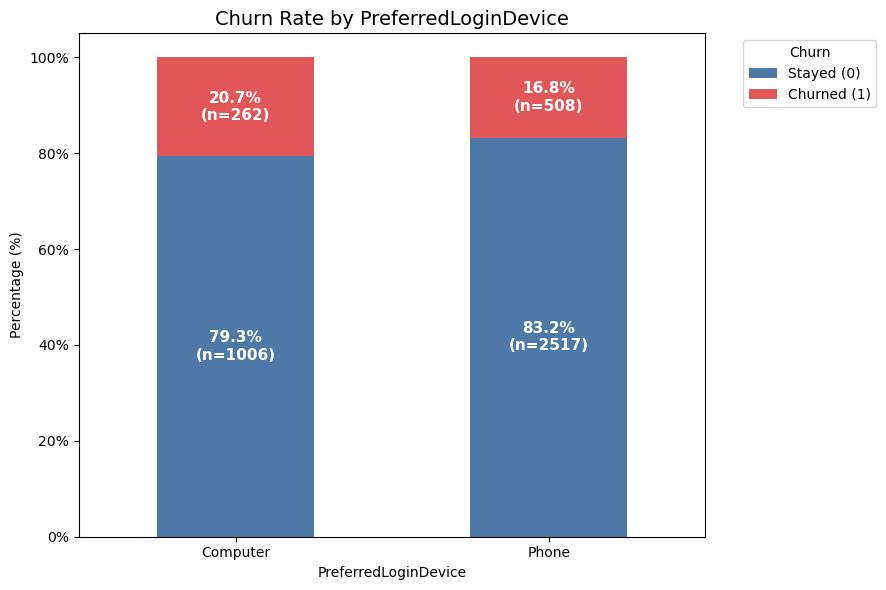

In [88]:
col = 'PreferredLoginDevice'

cross_tab_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
cross_tab_count = pd.crosstab(df[col], df['Churn'])

ax = cross_tab_pct.plot(kind='bar', stacked=True, color=['#4e79a7', '#e15759'], figsize=(9, 6))


for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            count = cross_tab_count.iloc[j, i]
            pct = cross_tab_pct.iloc[j, i]
            ax.text(bar.get_x() + bar.get_width()/2, 
                   bar.get_y() + height/2,
                   f'{pct:.1f}%\n(n={count})', 
                   ha='center', va='center', 
                   color='white', weight='bold', fontsize=11)

plt.title(f'Churn Rate by {col}', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel(col)
plt.legend(title='Churn', labels=['Stayed (0)', 'Churned (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

Customer who use Computer for login has higher churn rate (20.7%) compared to Phone users (16.8%).

In [89]:
col = 'PreferredLoginDevice'
crosstab = pd.crosstab(df[col], df['Churn'])
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Analysis for: {col}")
print(f"P-Value: {p:.4e}")
if p < 0.05:
    print(">> Result: Significant (The variables are related)")
else:
    print(">> Result: Not Significant (Likely random chance)")

print("\nContingency Table:")
print(crosstab)

Analysis for: PreferredLoginDevice
P-Value: 2.9698e-03
>> Result: Significant (The variables are related)

Contingency Table:
Churn                    0    1
PreferredLoginDevice           
Computer              1006  262
Phone                 2517  508


#### City Tier vs Churn

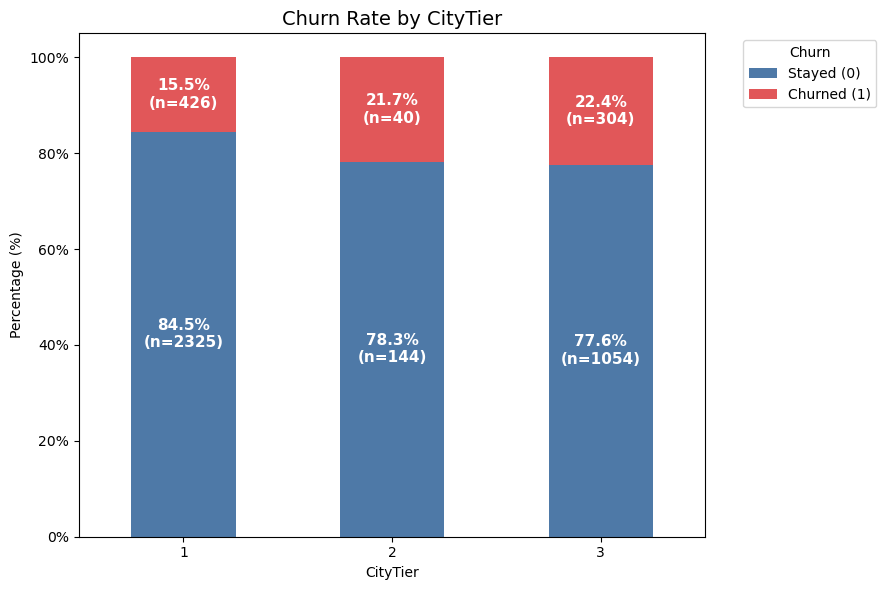

In [90]:
col = 'CityTier'
cross_tab_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
cross_tab_count = pd.crosstab(df[col], df['Churn'])

ax = cross_tab_pct.plot(kind='bar', stacked=True, color=['#4e79a7', '#e15759'], figsize=(9, 6))


for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            count = cross_tab_count.iloc[j, i]
            pct = cross_tab_pct.iloc[j, i]
            ax.text(bar.get_x() + bar.get_width()/2, 
                   bar.get_y() + height/2,
                   f'{pct:.1f}%\n(n={count})', 
                   ha='center', va='center', 
                   color='white', weight='bold', fontsize=11)

plt.title(f'Churn Rate by {col}', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel(col)
plt.legend(title='Churn', labels=['Stayed (0)', 'Churned (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

Assuming City Tier is an ordinal variable, there is a clear trend: the numerically lowest tier (Tier 1) has the lowest churn rate (15.5%), while the highest tier has the highest churn rate (20.7%). So, we can safely assume that people who live in the higher city tiers are more likely to churn.

In [91]:
col = 'CityTier'
crosstab = pd.crosstab(df[col], df['Churn'])
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Analysis for: {col}")
print(f"P-Value: {p:.4e}")
if p < 0.05:
    print(">> Result: Significant ")
else:
    print(">> Result: Not Significant ")

print("\nContingency Table:")
print(crosstab)

Analysis for: CityTier
P-Value: 1.5952e-07
>> Result: Significant 

Contingency Table:
Churn        0    1
CityTier           
1         2325  426
2         144   40 
3         1054  304


#### Gender vs Churn

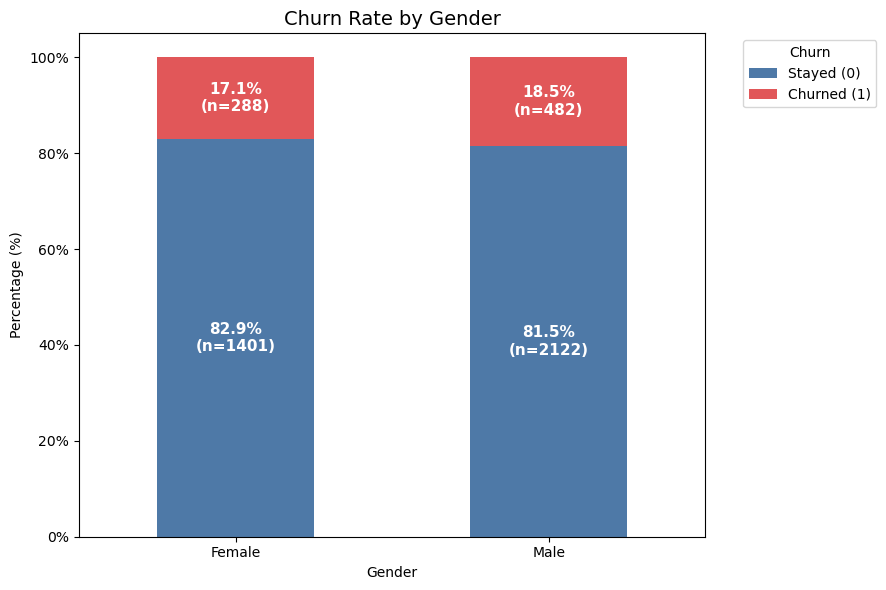

In [92]:
col = 'Gender'
cross_tab_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
cross_tab_count = pd.crosstab(df[col], df['Churn'])

ax = cross_tab_pct.plot(kind='bar', stacked=True, color=['#4e79a7', '#e15759'], figsize=(9, 6))


for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            count = cross_tab_count.iloc[j, i]
            pct = cross_tab_pct.iloc[j, i]
            ax.text(bar.get_x() + bar.get_width()/2, 
                   bar.get_y() + height/2,
                   f'{pct:.1f}%\n(n={count})', 
                   ha='center', va='center', 
                   color='white', weight='bold', fontsize=11)

plt.title(f'Churn Rate by {col}', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel(col)
plt.legend(title='Churn', labels=['Stayed (0)', 'Churned (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

There is a difference in churn rate between males and females, yet the difference is not significant. It is confirmed by the chi-square test, where the gender p-value is greater than 0.05. This means that there is no correlation between the difference in gender and whether they churned or not.

In [93]:
col = 'Gender'
crosstab = pd.crosstab(df[col], df['Churn'])
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Analysis for: {col}")
print(f"P-Value: {p:.6f}")
if p < 0.05:
    print(">> Result: Significant ")
else:
    print(">> Result: Not Significant ")

print("\nContingency Table:")
print(crosstab)

Analysis for: Gender
P-Value: 0.239569
>> Result: Not Significant 

Contingency Table:
Churn      0    1
Gender           
Female  1401  288
Male    2122  482


#### PreferedOrderCat vs Churn

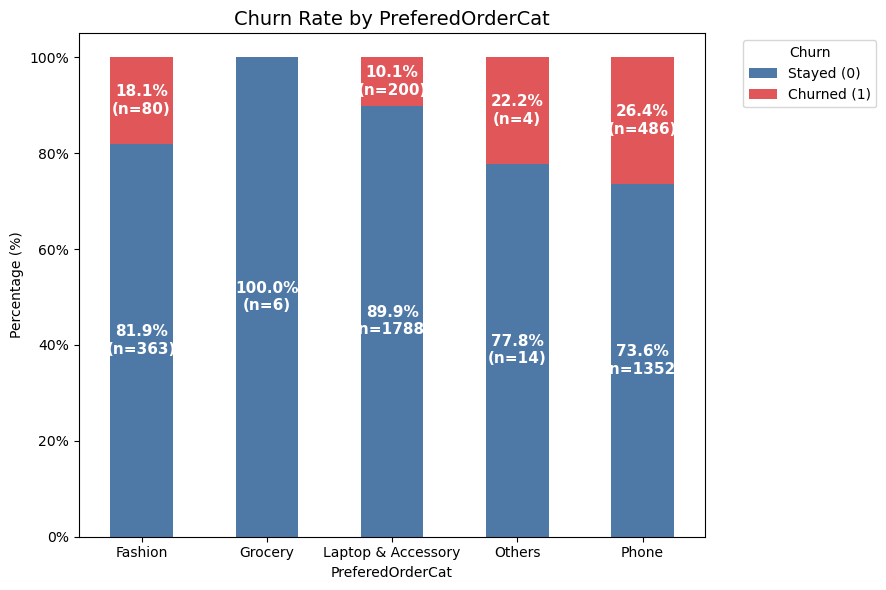

In [94]:
col = 'PreferedOrderCat'
cross_tab_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
cross_tab_count = pd.crosstab(df[col], df['Churn'])

ax = cross_tab_pct.plot(kind='bar', stacked=True, color=['#4e79a7', '#e15759'], figsize=(9, 6))


for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            count = cross_tab_count.iloc[j, i]
            pct = cross_tab_pct.iloc[j, i]
            ax.text(bar.get_x() + bar.get_width()/2, 
                   bar.get_y() + height/2,
                   f'{pct:.1f}%\n(n={count})', 
                   ha='center', va='center', 
                   color='white', weight='bold', fontsize=11)

plt.title(f'Churn Rate by {col}', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel(col)
plt.legend(title='Churn', labels=['Stayed (0)', 'Churned (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

There is a significant difference (proven by statistical tests) between Preferred Order Category and churn rate. People who bought Mobile Phones have the highest churn rate (26.4%); meanwhile, people who buy Grocery or Laptop & Accessory have the lowest churn rate. Therefore, we can conclude that product category preference  affects churn behavior.

In [95]:
col = 'PreferedOrderCat'
crosstab = pd.crosstab(df[col], df['Churn'])
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Analysis for: {col}")
print(f"P-Value: {p:.6f}")
if p < 0.05:
    print(">> Result: Significant ")
else:
    print(">> Result: Not Significant ")

print("\nContingency Table:")
print(crosstab)

Analysis for: PreferedOrderCat
P-Value: 0.000000
>> Result: Significant 

Contingency Table:
Churn                  0    1
PreferedOrderCat             
Fashion             363   80 
Grocery             6     0  
Laptop & Accessory  1788  200
Others              14    4  
Phone               1352  486


#### SatisfactionScore vs Churn

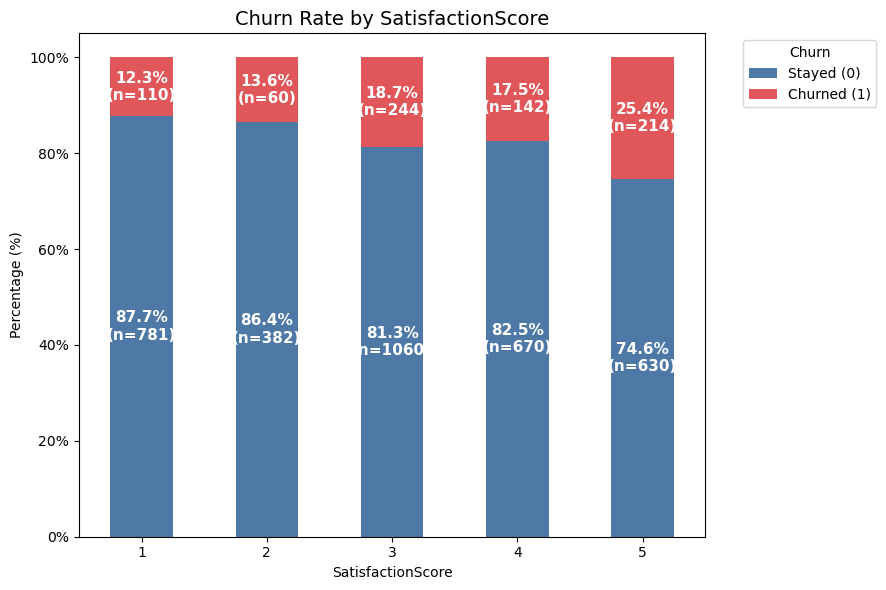

In [96]:
col = 'SatisfactionScore'
cross_tab_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
cross_tab_count = pd.crosstab(df[col], df['Churn'])

ax = cross_tab_pct.plot(kind='bar', stacked=True, color=['#4e79a7', '#e15759'], figsize=(9, 6))


for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            count = cross_tab_count.iloc[j, i]
            pct = cross_tab_pct.iloc[j, i]
            ax.text(bar.get_x() + bar.get_width()/2, 
                   bar.get_y() + height/2,
                   f'{pct:.1f}%\n(n={count})', 
                   ha='center', va='center', 
                   color='white', weight='bold', fontsize=11)

plt.title(f'Churn Rate by {col}', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel(col)
plt.legend(title='Churn', labels=['Stayed (0)', 'Churned (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

Although satisfaction score is an ordinal variable, there is no linear trend between the satisfaction score and the churn rate. We can see that people who are the most satisfied (score 5) have the highest churn rate (25.4%), which is higher than people who gave lower satisfaction ratings. On the other hand, even with this non-linear finding, statistical tests conclude that the difference in satisfaction scores is statistically significant in influencing churn behavior. this part need further investigation.

In [97]:
col = 'SatisfactionScore'
crosstab = pd.crosstab(df[col], df['Churn'])
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Analysis for: {col}")
print(f"P-Value: {p:.4e}")
if p < 0.05:
    print(">> Result: Significant ")
else:
    print(">> Result: Not Significant ")

print("\nContingency Table:")
print(crosstab)

Analysis for: SatisfactionScore
P-Value: 1.3376e-11
>> Result: Significant 

Contingency Table:
Churn                 0    1
SatisfactionScore           
1                  781   110
2                  382   60 
3                  1060  244
4                  670   142
5                  630   214


#### MaritalStatus vs Churn

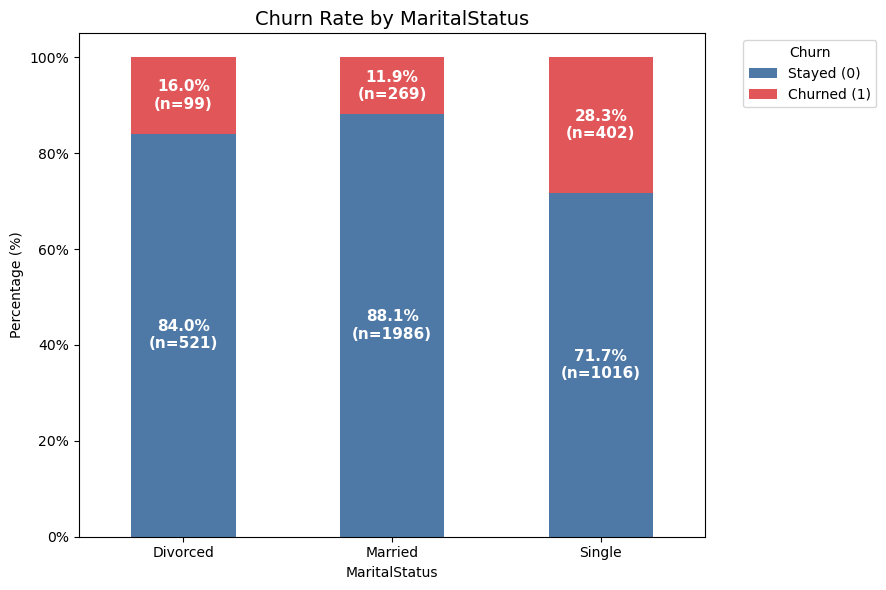

In [98]:
col = 'MaritalStatus'
cross_tab_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
cross_tab_count = pd.crosstab(df[col], df['Churn'])

ax = cross_tab_pct.plot(kind='bar', stacked=True, color=['#4e79a7', '#e15759'], figsize=(9, 6))


for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            count = cross_tab_count.iloc[j, i]
            pct = cross_tab_pct.iloc[j, i]
            ax.text(bar.get_x() + bar.get_width()/2, 
                   bar.get_y() + height/2,
                   f'{pct:.1f}%\n(n={count})', 
                   ha='center', va='center', 
                   color='white', weight='bold', fontsize=11)

plt.title(f'Churn Rate by {col}', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel(col)
plt.legend(title='Churn', labels=['Stayed (0)', 'Churned (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

Based on Chi-square statistical analysis, marital status significantly impacts churn. We can observe that Single customers are the most likely to churn (28.3%), whereas Married and Divorced customers show significantly higher retention rates.

In [99]:
col = 'MaritalStatus'
crosstab = pd.crosstab(df[col], df['Churn'])
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Analysis for: {col}")
print(f"P-Value: {p:.4e}")
if p < 0.05:
    print(">> Result: Significant ")
else:
    print(">> Result: Not Significant ")

print("\nContingency Table:")
print(crosstab)

Analysis for: MaritalStatus
P-Value: 9.0190e-36
>> Result: Significant 

Contingency Table:
Churn             0    1
MaritalStatus           
Divorced       521   99 
Married        1986  269
Single         1016  402


 #### Complain vs Churn

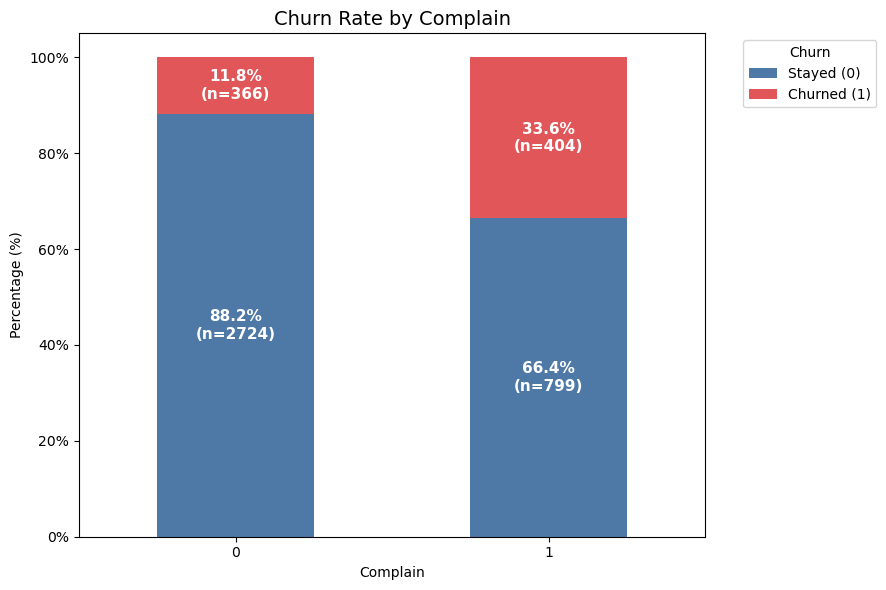

In [100]:
col = 'Complain'
cross_tab_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
cross_tab_count = pd.crosstab(df[col], df['Churn'])

ax = cross_tab_pct.plot(kind='bar', stacked=True, color=['#4e79a7', '#e15759'], figsize=(9, 6))


for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        height = bar.get_height()
        if height > 0:
            count = cross_tab_count.iloc[j, i]
            pct = cross_tab_pct.iloc[j, i]
            ax.text(bar.get_x() + bar.get_width()/2, 
                   bar.get_y() + height/2,
                   f'{pct:.1f}%\n(n={count})', 
                   ha='center', va='center', 
                   color='white', weight='bold', fontsize=11)

plt.title(f'Churn Rate by {col}', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel(col)
plt.legend(title='Churn', labels=['Stayed (0)', 'Churned (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

Customers who have raised complaints hava a significantly higher churn rate (33.6%) compared to only 11.8% for those wo didn't. By far, complain is the most significant categorical feature affecting churn behavior. 

In [101]:
col = 'Complain'
crosstab = pd.crosstab(df[col], df['Churn'])
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Analysis for: {col}")
print(f"P-Value: {p:.4e}")
if p < 0.05:
    print(">> Result: Significant ")
else:
    print(">> Result: Not Significant ")

print("\nContingency Table:")
print(crosstab)

Analysis for: Complain
P-Value: 4.3244e-62
>> Result: Significant 

Contingency Table:
Churn        0    1
Complain           
0         2724  366
1         799   404


#### **Categorical Bivariate Analysis Summary**

In [102]:
results_list = []

for col in categorical_cols:
    crosstab = pd.crosstab(df[col], df['Churn'])
    
    chi2, p, dof, expected = chi2_contingency(crosstab)
    results_list.append({
        'Feature': col,
        'P-Value': p,
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

summary_df = pd.DataFrame(results_list)
summary_df = summary_df.sort_values(by='P-Value', ascending=True).reset_index(drop=True)
pd.options.display.float_format = '{:.4e}'.format 

print(summary_df)

                Feature    P-Value Significant
0  Complain             4.3244e-62  Yes       
1  PreferedOrderCat     6.3857e-37  Yes       
2  MaritalStatus        9.0190e-36  Yes       
3  SatisfactionScore    1.3376e-11  Yes       
4  CityTier             1.5952e-07  Yes       
5  PreferredPaymentMode 2.5581e-06  Yes       
6  PreferredLoginDevice 2.9698e-03  Yes       
7  Gender               2.3957e-01  No        


- Based on statistical analysis, features like Complain, MaritalStatus, and PreferredOrderCat have a significant impact on churn behavior.  

- Every categorical feature in the dataset is statistically significant affecting churn except for Gender. This indicates that gender does not play a role in a customer's likelihood to churn; the nearly identical churn rates and a p-value > 0.05 confirm that.


### **3.4 Multivariate  Analysis**

#### **Tenure x SatisfactionScore vs Churn**

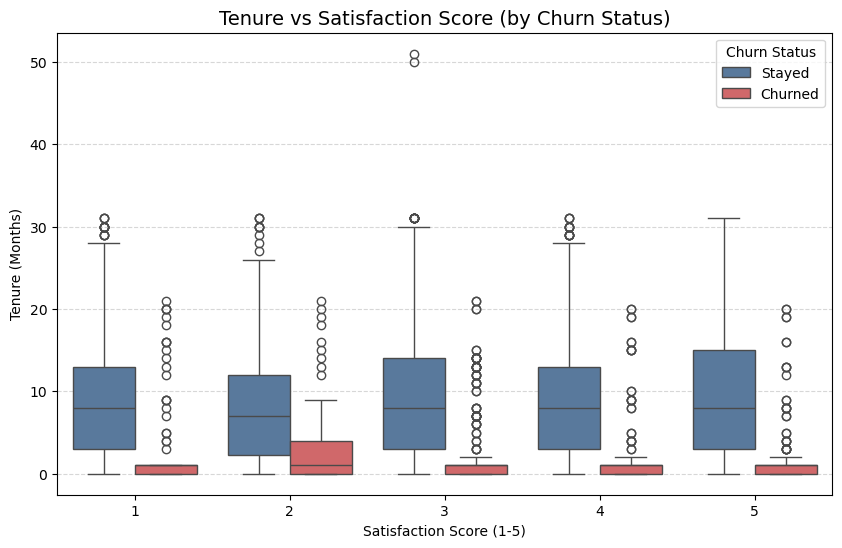

In [103]:
plt.figure(figsize=(10, 6))

ax = sns.boxplot(x='SatisfactionScore', y='Tenure', hue='Churn', data=df, palette=['#4e79a7', '#e15759'])

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Stayed', 'Churned'], title='Churn Status')

plt.title('Tenure vs Satisfaction Score (by Churn Status)', fontsize=14)
plt.ylabel('Tenure (Months)')
plt.xlabel('Satisfaction Score (1-5)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


Customers with **short tenures remain at high risk of churn**, **regardless of how satisfied they report themselves to be.**

#### **Tenure x Complain vs Churn**

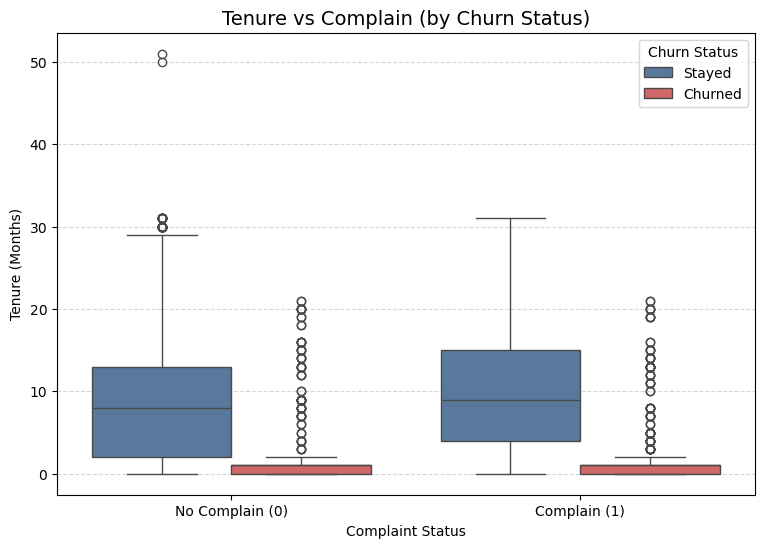

In [104]:
plt.figure(figsize=(9, 6))


ax = sns.boxplot(x='Complain', y='Tenure', hue='Churn', data=df, palette=['#4e79a7', '#e15759'])

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Complain (0)', 'Complain (1)'])

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Stayed', 'Churned'], title='Churn Status')

plt.title('Tenure vs Complain (by Churn Status)', fontsize=14)
plt.ylabel('Tenure (Months)')
plt.xlabel('Complaint Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Complaint status **amplifies churn risk primarily among low-tenure customers**, while **high-tenure customers remain relatively resilient even when complaints occur.**

#### **Ordercount x SatisfactionScore vs Churn**

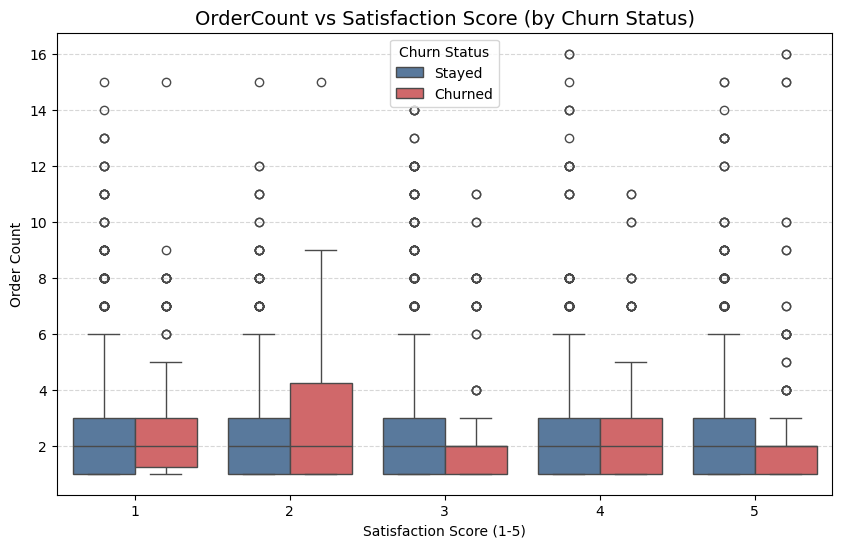

In [105]:
plt.figure(figsize=(10, 6))

ax = sns.boxplot(x='SatisfactionScore', y='OrderCount', hue='Churn', data=df, palette=['#4e79a7', '#e15759'])

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Stayed', 'Churned'], title='Churn Status')

plt.title('OrderCount vs Satisfaction Score (by Churn Status)', fontsize=14)
plt.ylabel('Order Count')
plt.xlabel('Satisfaction Score (1-5)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

The interaction between **satisfaction score and order count does not yield strong churn separation**, indicating that **transactional activity alone is insufficient to explain churn risk independently**.

In [106]:
df['OrderCount'].nunique()

16

## **4. Data Preprocessing**

### **4.1 Load Dataset**

In [107]:
df_modelling = pd.read_csv('data_preprocessed.csv')

### **4.2 Define X and y**

In [108]:
X = df_modelling.drop(columns=['Churn', 'CustomerID'])
y = df_modelling["Churn"]
customer_id = df_modelling['CustomerID']

### **4.3 Data Splitting**

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [110]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Tenure                       5366 non-null   float64
 1   PreferredLoginDevice         5630 non-null   object 
 2   CityTier                     5630 non-null   int64  
 3   WarehouseToHome              5379 non-null   float64
 4   PreferredPaymentMode         5630 non-null   object 
 5   Gender                       5630 non-null   object 
 6   HourSpendOnApp               5375 non-null   float64
 7   NumberOfDeviceRegistered     5630 non-null   int64  
 8   PreferedOrderCat             5630 non-null   object 
 9   SatisfactionScore            5630 non-null   int64  
 10  MaritalStatus                5630 non-null   object 
 11  NumberOfAddress              5630 non-null   int64  
 12  Complain                     5630 non-null   int64  
 13  OrderAmountHikeFro

### **4.4 Pipeline Development**

In [111]:
#ordinal features
ordinal_features = ['CityTier', 'SatisfactionScore']
#numerical features
numeric_features = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'NumberOfDeviceRegistered', 'NumberOfAddress',
    'OrderAmountHikeFromlastYear', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder']
#skewed numerical features
log_numeric_features = ['CashbackAmount']
#nominal categorical features
categorical_features = [
    'PreferedOrderCat', 'MaritalStatus',
    'PreferredLoginDevice', 'PreferredPaymentMode', 'Gender']
#binary features
binary_features = ['Complain']

In [112]:
#numeric pipeline with scaling
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

In [113]:
#numeric pipeline without scaling
numeric_pipeline2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [114]:
#skewed numeric pipeline with log transformation and scaling
log_numeric_pipeline = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', RobustScaler())
])

In [115]:
#skewed numeric pipeline without scaling
log_numeric_pipeline2 = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p))
])

In [116]:
#ordinal pipeline
ordinal_pipeline = Pipeline(steps=[
    ('ordinal_encoder', OrdinalEncoder(categories=[
        [1, 2, 3],  # CityTier
        [1, 2, 3, 4, 5]  # SatisfactionScore
    ]))
])

In [117]:
#nominal categorical pipeline with one hot encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot_encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

#### **Column Transformer**

In [118]:
#with scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('log', log_numeric_pipeline, log_numeric_features),
        ('bin', 'passthrough', binary_features),
        ('ord', ordinal_pipeline, ordinal_features),
        ('nom', categorical_pipeline, categorical_features),
    ],
    remainder='drop'
)

In [119]:
#without scaling
preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline2, numeric_features),
        ('log', log_numeric_pipeline2, log_numeric_features),
        ('bin', 'passthrough', binary_features),
        ('ord', ordinal_pipeline, ordinal_features),
        ('nom', categorical_pipeline, categorical_features),
    ],
    remainder='drop'
)

In [120]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                                  'NumberOfDeviceRegistered', 'NumberOfAddress',
                                  'OrderAmountHikeFromlastYear', 'CouponUsed',
                                  'OrderCount', 'DaySinceLastOrder']),
                                ('log',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(func...
                                ('bin', 'passthrough', ['Complain']),
                                ('ord',
                                 Pipeline(steps=[('ordinal_encoder',
                                                  OrdinalEncoder(categories=[[1,
                                                                              2,
                                                                              3],
                                                                             [1,
                                                                              2,
                                                                              3,
                                                                              4,
                                                                              5]]))]),
                                 ['CityTier', 'SatisfactionScore']),
                                ('nom',
                                 Pipeline(steps=[('onehot_encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['PreferedOrderCat', 'MaritalStatus',
                                  'PreferredLoginDevice',
                                  'PreferredPaymentMode', 'Gender'])])

In [121]:
preprocessor2

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                                  'NumberOfDeviceRegistered', 'NumberOfAddress',
                                  'OrderAmountHikeFromlastYear', 'CouponUsed',
                                  'OrderCount', 'DaySinceLastOrder']),
                                ('log',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>))]),
                                 ['Cash...
                                ('bin', 'passthrough', ['Complain']),
                                ('ord',
                                 Pipeline(steps=[('ordinal_encoder',
                                                  OrdinalEncoder(categories=[[1,
                                                                              2,
                                                                              3],
                                                                             [1,
                                                                              2,
                                                                              3,
                                                                              4,
                                                                              5]]))]),
                                 ['CityTier', 'SatisfactionScore']),
                                ('nom',
                                 Pipeline(steps=[('onehot_encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['PreferedOrderCat', 'MaritalStatus',
                                  'PreferredLoginDevice',
                                  'PreferredPaymentMode', 'Gender'])])

In [122]:
y_train.value_counts(normalize=True)

Churn
0   8.3171e-01
1   1.6829e-01
Name: proportion, dtype: float64

## **5. Model Development and Evaluation**

Model selection was **primarily guided by the F2-score**, as the task emphasizes recall of churn customers. 
**Cross-validation was conducted under three strategies—baseline, resampling, and class-weighted modeling—**
to ensure robust comparison across different imbalance-handling approaches.

### **5.1 Cross Validation**

In [123]:
#define algo
logreg = LogisticRegression(random_state=42)
knn = KNeighborsClassifier()
tree = DecisionTreeClassifier(random_state=42)
#random forest
rf = RandomForestClassifier(random_state=42)
#gradient boosting
adaboost = AdaBoostClassifier(random_state=42)
gboost = GradientBoostingClassifier(random_state=42)
xgboost = XGBClassifier(random_state=42)

In [124]:
f2_scorer = make_scorer(fbeta_score, beta=2)

In [125]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [126]:
start_time = time.time()
#cross val scaling
list_model = [knn, logreg]
list_all_score = []
list_mean_score = []
list_std = []

for model in list_model:
    # pipeline
    pipe_prep_model =  Pipeline([
        ('preprocessing', preprocessor),
        ('modeling', model)
    ])

    # cross val
    crossval = cross_val_score(estimator=pipe_prep_model,
                    X = X_train,
                    y = y_train,
                    cv = skf,
                    scoring = f2_scorer)

    
    # recall
    list_all_score.append(crossval.round(2))
    list_mean_score.append(crossval.mean())
    list_std.append(crossval.std())
    
end_time = time.time()
elapsed = end_time - start_time
print(f"Total running time: {elapsed:.2f} seconds") 

Total running time: 1.17 seconds


In [127]:
#cross val tanpa scaling
list_model2 = [tree, rf, adaboost, gboost, xgboost]
list_all_score2 = []
list_mean_score2 = []
list_std2 = []
list_time = []

for model in list_model2:
    start = time.time()
    # pipeline
    pipe_prep_model =  Pipeline([
        ('preprocessing', preprocessor2),
        ('modeling', model)
    ])

    # cross val
    crossval = cross_val_score(estimator=pipe_prep_model,
                    X = X_train,
                    y = y_train,
                    cv = skf,
                    scoring = f2_scorer)
    end = time.time()
    
    # recall
    list_all_score2.append(crossval.round(2))
    list_mean_score2.append(crossval.mean())
    list_std2.append(crossval.std())
    list_time.append(round(end - start, 2))

In [128]:
df_cv = pd.DataFrame({
    'Model': [m.__class__.__name__ for m in list_model],
    'All F2 Scores': list_all_score,
    'Mean F2': list_mean_score,
    'Std F2': list_std,
    'Time (s)' : round(elapsed,2)
}).sort_values(by=['Mean F2', 'Std F2'], ascending=[False, True]).reset_index(drop=True)
df_cv

,Model,All F2 Scores,Mean F2,Std F2,Time (s)
0,LogisticRegression,"[0.55, 0.53, 0.45, 0.64, 0.59]",5.5262e-01,6.3070e-02,1.1700e+00
1,KNeighborsClassifier,"[0.52, 0.51, 0.56, 0.48, 0.52]",5.1794e-01,2.3760e-02,1.1700e+00


In [129]:
df_cv2 = pd.DataFrame({
    'Model': [m.__class__.__name__ for m in list_model2],
    'All F2 Scores': list_all_score2,
    'Mean F2': list_mean_score2,
    'Std F2': list_std2,
    'Time (s)': list_time
}).sort_values(by=['Mean F2', 'Std F2'], ascending=[False, True]).reset_index(drop=True)
df_cv2

,Model,All F2 Scores,Mean F2,Std F2,Time (s)
0,XGBClassifier,"[0.87, 0.87, 0.83, 0.84, 0.82]",8.4640e-01,2.1911e-02,2.6800e+00
1,DecisionTreeClassifier,"[0.83, 0.79, 0.82, 0.78, 0.82]",8.0773e-01,1.9719e-02,4.6000e-01
2,RandomForestClassifier,"[0.8, 0.82, 0.71, 0.82, 0.79]",7.8672e-01,4.2186e-02,3.2500e+00
3,GradientBoostingClassifier,"[0.6, 0.69, 0.55, 0.7, 0.69]",6.4584e-01,5.8207e-02,3.9800e+00
4,AdaBoostClassifier,"[0.63, 0.56, 0.5, 0.6, 0.63]",5.8640e-01,4.7844e-02,1.5400e+00


In [130]:
df_cv_all = pd.concat([df_cv, df_cv2], ignore_index=True).sort_values(by=['Mean F2', 'Std F2'], ascending=[False, True]).reset_index(drop=True)
df_cv_all

,Model,All F2 Scores,Mean F2,Std F2,Time (s)
0,XGBClassifier,"[0.87, 0.87, 0.83, 0.84, 0.82]",8.4640e-01,2.1911e-02,2.6800e+00
1,DecisionTreeClassifier,"[0.83, 0.79, 0.82, 0.78, 0.82]",8.0773e-01,1.9719e-02,4.6000e-01
2,RandomForestClassifier,"[0.8, 0.82, 0.71, 0.82, 0.79]",7.8672e-01,4.2186e-02,3.2500e+00
3,GradientBoostingClassifier,"[0.6, 0.69, 0.55, 0.7, 0.69]",6.4584e-01,5.8207e-02,3.9800e+00
4,AdaBoostClassifier,"[0.63, 0.56, 0.5, 0.6, 0.63]",5.8640e-01,4.7844e-02,1.5400e+00
5,LogisticRegression,"[0.55, 0.53, 0.45, 0.64, 0.59]",5.5262e-01,6.3070e-02,1.1700e+00
6,KNeighborsClassifier,"[0.52, 0.51, 0.56, 0.48, 0.52]",5.1794e-01,2.3760e-02,1.1700e+00


### **5.2 Cross Validation + Resampling**

In [131]:
resamplers = {
    'SMOTE': SMOTE(sampling_strategy='minority', random_state=42),
    'RandomOver': RandomOverSampler(sampling_strategy='minority', random_state=42),
    'RandomUnder': RandomUnderSampler(sampling_strategy='majority', random_state=42)
}

In [132]:
preprocessors = {
    'with_scaling': preprocessor,
    'without_scaling': preprocessor2
}

In [133]:
models = {
    'with_scaling': [knn, logreg],
    'without_scaling': [tree, rf, adaboost, gboost, xgboost]
}

In [134]:
results = []

for prep_name, prep in preprocessors.items():
    for res_name, res in resamplers.items():
        for model in models[prep_name]:
            start = time.time()
            pipe = Pipeline([
                ('preprocessing', prep),
                ('resampling', res),
                ('modeling', model)
            ])
            
            scores = cross_val_score(
                estimator=pipe,
                X=X_train,
                y=y_train,
                cv=skf,
                scoring=f2_scorer
            )
            end = time.time()
            
            results.append({
                'Resampling': res_name,
                'Model': model.__class__.__name__,
                'All F2 Scores': scores.round(2).tolist(),
                'Mean F2 Scores': scores.mean(),
                'Std F2 Scores': scores.std(),
                'Time (s)' : (round(end - start, 2))
            })

df_results = pd.DataFrame(results).sort_values(by=['Mean F2 Scores', 'Std F2 Scores'], ascending=[False, True]).reset_index(drop=True)
df_results

,Resampling,Model,All F2 Scores,Mean F2 Scores,Std F2 Scores,Time (s)
0,RandomOver,XGBClassifier,"[0.91, 0.88, 0.85, 0.86, 0.82]",8.6217e-01,3.0921e-02,1.5600e+00
1,RandomOver,RandomForestClassifier,"[0.86, 0.86, 0.82, 0.85, 0.82]",8.4417e-01,1.9919e-02,3.8900e+00
2,RandomUnder,RandomForestClassifier,"[0.86, 0.86, 0.81, 0.84, 0.82]",8.3752e-01,2.1489e-02,1.8800e+00
3,RandomUnder,XGBClassifier,"[0.86, 0.82, 0.82, 0.81, 0.84]",8.2972e-01,1.8081e-02,1.2800e+00
4,SMOTE,XGBClassifier,"[0.85, 0.84, 0.78, 0.81, 0.82]",8.2065e-01,2.6717e-02,2.4700e+00
5,SMOTE,RandomForestClassifier,"[0.8, 0.81, 0.74, 0.82, 0.81]",7.9711e-01,2.7987e-02,6.0400e+00
6,SMOTE,KNeighborsClassifier,"[0.82, 0.78, 0.79, 0.81, 0.75]",7.9093e-01,2.3736e-02,6.3000e-01
7,RandomOver,KNeighborsClassifier,"[0.82, 0.78, 0.79, 0.8, 0.76]",7.8889e-01,1.9116e-02,5.8000e-01
8,RandomOver,DecisionTreeClassifier,"[0.83, 0.79, 0.78, 0.8, 0.73]",7.8755e-01,3.2702e-02,4.9000e-01
9,RandomOver,GradientBoostingClassifier,"[0.81, 0.78, 0.72, 0.81, 0.76]",7.7650e-01,3.1112e-02,5.9700e+00


### **5.3 Cross Validation + Penalized Model (class_weight='balanced')**

In [135]:
tree_bal = DecisionTreeClassifier(class_weight='balanced', random_state=42)
rf_bal = RandomForestClassifier(class_weight='balanced', random_state=42)

In [136]:
base_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)
adaboost_bal = AdaBoostClassifier(estimator=base_tree, random_state=42)

In [137]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
ratio
xgboost_bal = XGBClassifier(scale_pos_weight=ratio, random_state=42)

In [138]:
#cross val tanpa scaling
list_model_bal = [tree_bal, rf_bal, adaboost_bal, xgboost_bal]
list_all_score_bal = []
list_mean_score_bal = []
list_std_bal = []
list_time = []

for model in list_model_bal:
    start = time.time()
    # pipeline
    pipe_prep_model =  Pipeline([
        ('preprocessing', preprocessor2),
        ('modeling', model)
    ])

    # cross val
    crossval = cross_val_score(estimator=pipe_prep_model,
                    X = X_train,
                    y = y_train,
                    cv = skf,
                    scoring = f2_scorer)
    end = time.time()
    
    # recall
    list_all_score_bal.append(crossval.round(2))
    list_mean_score_bal.append(crossval.mean())
    list_std_bal.append(crossval.std())
    list_time.append(round(end - start, 2))

In [139]:
df_cv_bal = pd.DataFrame({
    'Model': [m.__class__.__name__ for m in list_model_bal],
    'All F2 Scores': list_all_score_bal,
    'Mean F2': list_mean_score_bal,
    'Std F2': list_std_bal,
    'Time (s)' : list_time
}).sort_values(by=['Mean F2', 'Std F2'], ascending=[False, True]).reset_index(drop=True)
df_cv_bal

,Model,All F2 Scores,Mean F2,Std F2,Time (s)
0,XGBClassifier,"[0.91, 0.88, 0.85, 0.87, 0.84]",8.6872e-01,2.3841e-02,1.5100e+00
1,RandomForestClassifier,"[0.77, 0.82, 0.73, 0.81, 0.76]",7.7743e-01,3.2723e-02,3.1300e+00
2,DecisionTreeClassifier,"[0.8, 0.79, 0.75, 0.73, 0.77]",7.6784e-01,2.2888e-02,5.0000e-01
3,AdaBoostClassifier,"[0.79, 0.76, 0.73, 0.71, 0.78]",7.5558e-01,2.8371e-02,3.9000e-01


### **5.4 Cross Validation Ranking**

In [140]:
#Hasil Score Cross Validation tanpa resampling dan tanpa class weight
df_cv_all.head(2)

,Model,All F2 Scores,Mean F2,Std F2,Time (s)
0,XGBClassifier,"[0.87, 0.87, 0.83, 0.84, 0.82]",8.4640e-01,2.1911e-02,2.6800e+00
1,DecisionTreeClassifier,"[0.83, 0.79, 0.82, 0.78, 0.82]",8.0773e-01,1.9719e-02,4.6000e-01


In [141]:
#Hasil Score Cross Validation dengan Resampling
df_results.head(2)

,Resampling,Model,All F2 Scores,Mean F2 Scores,Std F2 Scores,Time (s)
0,RandomOver,XGBClassifier,"[0.91, 0.88, 0.85, 0.86, 0.82]",8.6217e-01,3.0921e-02,1.5600e+00
1,RandomOver,RandomForestClassifier,"[0.86, 0.86, 0.82, 0.85, 0.82]",8.4417e-01,1.9919e-02,3.8900e+00


In [142]:
#Hasil Score Cross Validation dengan class weight
df_cv_bal.head(2)

,Model,All F2 Scores,Mean F2,Std F2,Time (s)
0,XGBClassifier,"[0.91, 0.88, 0.85, 0.87, 0.84]",8.6872e-01,2.3841e-02,1.5100e+00
1,RandomForestClassifier,"[0.77, 0.82, 0.73, 0.81, 0.76]",7.7743e-01,3.2723e-02,3.1300e+00


Cross-validation results indicate that cost-sensitive learning using class-weighted models achieves the highest average F2-score, outperforming both baseline and resampling-based approaches. Therefore, class-weighted XGBoost is selected as the primary candidate for hyperparameter tuning, with resampling-based XGBoost retained as a comparative benchmark.

In [143]:
pipe_benchmark = Pipeline([
    ('preprocessing', preprocessor2),
    ('modeling', xgboost_bal)
])
pipe_benchmark.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder']),
                                                 ('log',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransform...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

### **5.5 Hyperparameter Tuning**

Tuning XGBoost Penalized Model

In [144]:
XGBClassifier()

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [145]:
#hyperparam
hyperparam = {
    'modeling__n_estimators': [200, 400],
    'modeling__learning_rate': [0.05, 0.1],
    'modeling__max_depth': [3, 4, 5],
    'modeling__subsample': [0.8, 1.0],
    'modeling__colsample_bytree': [0.8, 1.0],
}

In [146]:
#pipeline
pipe_tune_xgboost = Pipeline([
    ('preprocessing', preprocessor2),
    ('modeling', xgboost_bal)
]).set_output(transform='pandas')

In [147]:
grid_search = GridSearchCV(
    estimator=pipe_tune_xgboost,
    param_grid=hyperparam,
    scoring=f2_scorer,
    cv=skf,
    n_jobs=-1,
    verbose=2
)
grid_search

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['Tenure',
                                                                          'WarehouseToHome',
                                                                          'HourSpendOnApp',
                                                                          'NumberOfDeviceRegistered',
                                                                          'NumberOfAddress',
                                                                          'OrderAmountHikeFromlastYear',
                                                                          'CouponUsed'...
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'modeling__colsample_bytree': [0.8, 1.0],
                         'modeling__learning_rate': [0.05, 0.1],
                         'modeling__max_depth': [3, 4, 5],
                         'modeling__n_estimators': [200, 400],
                         'modeling__subsample': [0.8, 1.0]},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=2),
             verbose=2)

In [148]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['Tenure',
                                                                          'WarehouseToHome',
                                                                          'HourSpendOnApp',
                                                                          'NumberOfDeviceRegistered',
                                                                          'NumberOfAddress',
                                                                          'OrderAmountHikeFromlastYear',
                                                                          'CouponUsed'...
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'modeling__colsample_bytree': [0.8, 1.0],
                         'modeling__learning_rate': [0.05, 0.1],
                         'modeling__max_depth': [3, 4, 5],
                         'modeling__n_estimators': [200, 400],
                         'modeling__subsample': [0.8, 1.0]},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=2),
             verbose=2)

In [149]:
print("Best Parameters:", grid_search.best_params_)
print("Best F2 Score (CV):", grid_search.best_score_)

Best Parameters: {'modeling__colsample_bytree': 0.8, 'modeling__learning_rate': 0.1, 'modeling__max_depth': 5, 'modeling__n_estimators': 200, 'modeling__subsample': 0.8}
Best F2 Score (CV): 0.8680711739686192


#### **Check 2nd best CV Model**

In [150]:
param_xgb_ros = {
    'modeling__n_estimators': [200, 400],
    'modeling__max_depth': [3, 4],
}

In [151]:
#pipeline
pipe_xgboost_ros = Pipeline([
    ('preprocessing', preprocessor2),
    ('resampling', RandomOverSampler(sampling_strategy='minority', random_state=42)),
    ('modeling', xgboost)
]).set_output(transform='pandas')

In [152]:
grid_search_ros = GridSearchCV(
    estimator=pipe_xgboost_ros,
    param_grid=param_xgb_ros,
    scoring=f2_scorer,
    cv=skf,
    n_jobs=-1,
    verbose=2
)
grid_search_ros
grid_search_ros.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['Tenure',
                                                                          'WarehouseToHome',
                                                                          'HourSpendOnApp',
                                                                          'NumberOfDeviceRegistered',
                                                                          'NumberOfAddress',
                                                                          'OrderAmountHikeFromlastYear',
                                                                          'CouponUsed'...
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'modeling__max_depth': [3, 4],
                         'modeling__n_estimators': [200, 400]},
             scoring=make_scorer(fbeta_score, response_method='predict', beta=2),
             verbose=2)

In [153]:
print("Best Parameters:", grid_search_ros.best_params_)
print("Best F2 Score (CV):", grid_search_ros.best_score_)

Best Parameters: {'modeling__max_depth': 3, 'modeling__n_estimators': 400}
Best F2 Score (CV): 0.8610076053123696


Two imbalance-handling strategies were evaluated: cost-sensitive learning and data-level resampling. While RandomOverSampling was tested as a benchmark, the cost-sensitive XGBoost model consistently achieved higher F2-scores with lower variance. **Therefore, the penalized XGBoost model was selected as the final model**.

#### **F2 Score Before-After Tuning on Train Set**

**XGB Penalized Model**
- Benchmark model XGBoost : 0.8687
- Hyperparameter tuning XGBoost : 0.8681

Hyperparameter tuning on the penalized XGBoost model did not result in a meaningful improvement in F2-score compared to the benchmark configuration. The marginal difference indicates that the baseline model was already near-optimal for this dataset. Therefore, the tuned model is selected based on stability and consistency rather than marginal score gains.

In [154]:
pipe_tuned = grid_search.best_estimator_
pipe_tuned

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder']),
                                                 ('log',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransform...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

### **5.6 Evaluate on Test Set**

In [155]:
y_train_base = pipe_benchmark.predict(X_train)
y_test_base = pipe_benchmark.predict(X_test)

f2_train_base = fbeta_score(y_train, y_train_base, beta=2)
f2_test_base = fbeta_score(y_test, y_test_base, beta=2)

print(f"F2 Train (Base Model): {f2_train_base}")
print(f"F2 Test (Base Model): {f2_test_base}")

F2 Train (Base Model): 1.0
F2 Test (Base Model): 0.976890756302521


In [156]:
y_train_tuned = pipe_tuned.predict(X_train)
y_test_tuned = pipe_tuned.predict(X_test)

f2_train_tuned = fbeta_score(y_train, y_train_tuned, beta=2)
f2_test_tuned = fbeta_score(y_test, y_test_tuned, beta=2)

print(f"F2 Train (Tuned Model): {f2_train_tuned}")
print(f"F2 Test (Tuned Model): {f2_test_tuned}")

F2 Train (Tuned Model): 0.9908496732026144
F2 Test (Tuned Model): 0.9713701431492843


In [157]:
y_train_proba_base = pipe_benchmark.predict_proba(X_train)[:, 1]
y_test_proba_base = pipe_benchmark.predict_proba(X_test)[:, 1]

y_train_proba_tuned = pipe_tuned.predict_proba(X_train)[:, 1]
y_test_proba_tuned = pipe_tuned.predict_proba(X_test)[:, 1]

### **5.7 Classification Report on Test Set**

In [158]:
print('XGBoost Before Tuning')
print(classification_report(y_test, y_test_base))

XGBoost Before Tuning
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       936
           1       0.97      0.98      0.97       190

    accuracy                           0.99      1126
   macro avg       0.98      0.99      0.98      1126
weighted avg       0.99      0.99      0.99      1126



Before tuning, the **XGBoost model demonstrates a well-balanced performance**, achieving **high precision and recall for both churn and non-churn classes**. However, **the model still misses a small number of churn customers**, as indicated by **the presence of false negatives**. While false positives remain minimal, **missed churn cases pose a higher business risk in a churn prevention context**.

In [159]:
print('XGBoost After Tuning')
print(classification_report(y_test, y_test_tuned))

XGBoost After Tuning
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       936
           1       0.87      1.00      0.93       190

    accuracy                           0.98      1126
   macro avg       0.94      0.99      0.96      1126
weighted avg       0.98      0.98      0.98      1126



After tuning, the model shifts toward a recall-oriented strategy for the churn class. **The tuned model successfully captures all churn customers**, eliminating false negatives entirely. This improvement **comes with an increase in false positives, as some non-churn customers are incorrectly flagged as churn.** 


Having said that, **this trade-off is intentional and aligned with the business objective of minimizing missed churn cases, where the cost of losing a customer outweighs the cost of unnecessary intervention.**

### **5.8 PR AUC Validation (Overfit and Leakage Check)**

PR AUC is used to assess overfitting and potential data leakage because it directly reflects precision–recall behavior under class imbalance, making it more sensitive to unrealistic performance gaps between training and test sets.

In [160]:
from sklearn.metrics import average_precision_score

In [161]:
# Base model
pr_auc_train_base = average_precision_score(y_train, y_train_proba_base)
pr_auc_test_base = average_precision_score(y_test, y_test_proba_base)

# Tuned model
pr_auc_train_tuned = average_precision_score(y_train, y_train_proba_tuned)
pr_auc_test_tuned = average_precision_score(y_test, y_test_proba_tuned)

In [162]:
print(f"Base Model - PR AUC Train: {pr_auc_train_base:.3f}")
print(f"Base Model - PR AUC Test : {pr_auc_test_base:.3f}")
print()
print(f"Tuned Model - PR AUC Train: {pr_auc_train_tuned:.3f}")
print(f"Tuned Model - PR AUC Test : {pr_auc_test_tuned:.3f}")

Base Model - PR AUC Train: 1.000
Base Model - PR AUC Test : 0.997

Tuned Model - PR AUC Train: 0.999
Tuned Model - PR AUC Test : 0.980


**Summary :**

PR AUC results indicate no evidence of data leakage, as both training and test performance remain consistently high. The strong performance is **primarily driven by clear behavioral separation in key features, such as tenure.** 

The tuned model shows a slightly larger generalization gap, supporting the selection of the baseline penalized XGBoost model for stability.

### **5.9 Confusion Matrix**

In [163]:
y_test_pred_base = pipe_benchmark.predict(X_test)

In [164]:
y_test_pred_tuned = pipe_tuned.predict(X_test)

In [165]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [166]:
#calculate confusion matrix
conf_matrix_base = confusion_matrix(y_test, y_test_pred_base)
conf_matrix_tuned = confusion_matrix(y_test, y_test_pred_tuned)

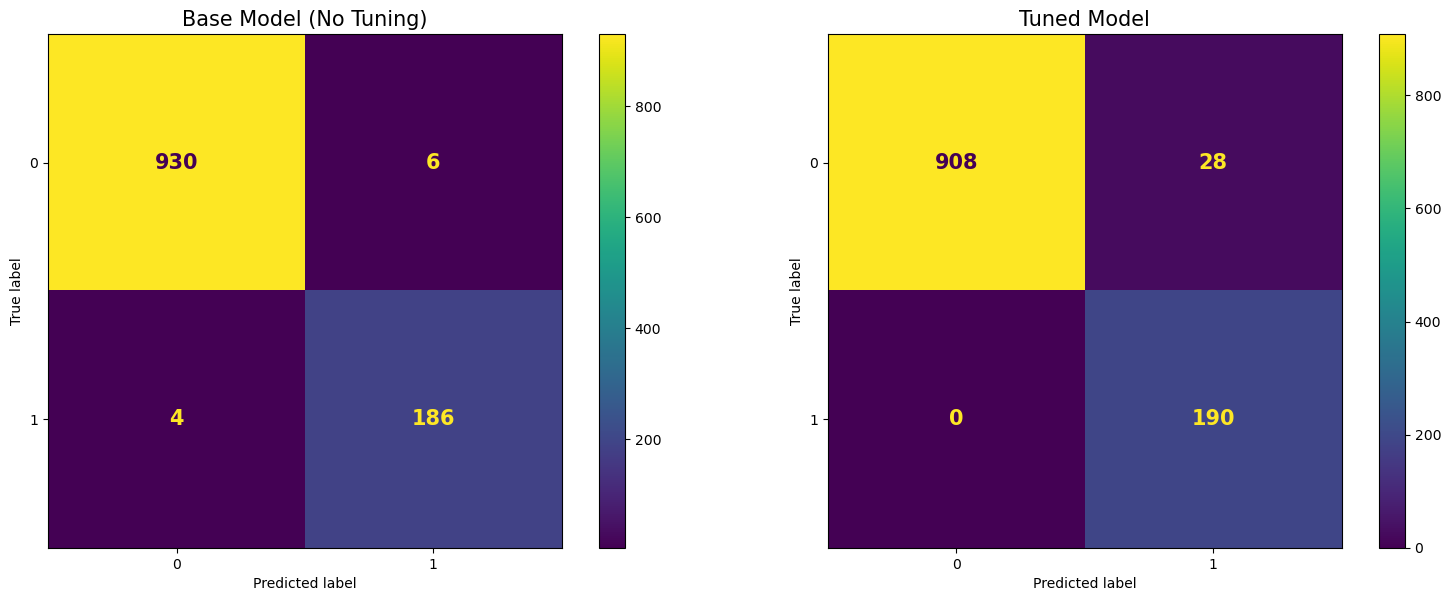

In [167]:
# Visualize confusion matrices
figure, axes = plt.subplots(ncols=2, figsize=(16, 6))

text_format = {'size': 15, 'weight': 'bold'}

ConfusionMatrixDisplay(conf_matrix_base).plot(ax=axes[0], text_kw=text_format)
axes[0].set_title("Base Model (No Tuning)", fontsize=15)

ConfusionMatrixDisplay(conf_matrix_tuned).plot(ax=axes[1], text_kw=text_format)
axes[1].set_title("Tuned Model", fontsize=15)

plt.tight_layout()
plt.show()

Before Tuning - XGBoostClassifier

- True Negative (TN) : 930 customers not churn, and successfully predicted as not churn
- True Positive (TP) : 186 customers churn successfully predicted by the model
- False Negative (FN) : 4 customers churn but predicted as not churn by the model
- False Positive (FP) : 6 customers not churn but predicted as churn by the model

After Tuning - XGBoostClassifier
- True Negative (TN) : 908 customers not churn, and successfully predicted as not churn
- True Positive (TP) : 190 customers churn successfully predicted by the model
- False Negative (FN) : 0 customers churn but predicted as not churn by the model
- False Positive (FP) : 28 customers not churn but predicted as churn by the model

In [168]:
y_test.value_counts()

Churn
0    936
1    190
Name: count, dtype: int64

### **5.10 Business Impact Analysis**

**Cost Definitions**\
As previously defined in the business problem:

- **False Positive (FP):**
The model predicts that a customer is at high-risk of churning, prompting the company to offer a retention promotion worth **$5**, even though the customer would is not at high-risk of churning.
- **False Negative (FN):**
The model fails to identify a high-risk customer, resulting in no retention action being taken and the loss of a high-value customer worth **$70**.

**Assumption**: Customers who receive a retention promotion will remain active (i.e., will not churn).

#### **Without Machine Learning**

As a worst-case scenario, without using machine learning, the company adopts a defensive strategy by offering promotions to all customers to avoid the risk of losing high-value customers, given that the cost of losing a customer is significantly higher than the cost of retention incentives.

This approach is not cost-efficient, but it is used as an extreme baseline to illustrate the potential cost savings achievable through churn prediction models.

|                 | Predicted (0) | Predicted (1) |
| :-------------: | :-----------: | :-----------: |
| Actual (0)      | 0             | 936          |
| Actual (1)      | 0             | 190           |

- **Total promotion cost (all customers):**
1126 × $5 = **$5,630**
- **Effective promotions (churned customers):**
190 × $5 = **$950**
- **Wasted promotion cost (loyal customers):**
936 × $5 = **$4,680**

#### **With Machine Learning**

By applying a churn prediction model, the company can target retention efforts only toward customers who are predicted to churn.

|                 | Predicted (0) | Predicted (1) |
| :-------------: | :-----------: | :-----------: |
| Actual (0)      | 908	          | 28           |
| Actual (1)      | 0            | 190           |

- **False Positive cost (FP):**
28 × $5 = **$140** (promotion cost for loyal customers)
- **False Negative cost (FN):**
0 × $60 = **$0** (no churned customers missed)
- **Total expected cost:**
**$140**

#### **Model Impact Conclusion**

The implementation of Machine Learning significantly reduces ineffective retention costs. By eliminating False Negatives, the model ensures that no churning customers are missed without intervention. Compared to the defensive strategy without a predictive model, the total expected cost is reduced from $5,630 to $140, representing an approximate **97,5% reduction in potential losses**.

### **5.11 Feature Importance**

In [169]:
pipe_tuned

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder']),
                                                 ('log',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransform...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [170]:
preprocessor = pipe_tuned.named_steps['preprocessing']
model = pipe_tuned.named_steps['modeling']

In [171]:
X_train_shap = preprocessor.transform(X_train)
X_test_shap = preprocessor.transform(X_test)

In [172]:
X_train_shap = np.array(X_train_shap)
X_test_shap = np.array(X_test_shap)

In [173]:
import shap

explainer = shap.TreeExplainer(model)

In [174]:
shap_values = explainer.shap_values(X_test_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]  # class Churn

In [175]:
feature_names = []

# 1. numeric features
feature_names.extend(numeric_features)

# 2. log-transformed numeric features
feature_names.extend([f'log_{f}' for f in log_numeric_features])

# 3. binary features
feature_names.extend(binary_features)

# 4. ordinal features
feature_names.extend(ordinal_features)

# 5. one-hot encoded categorical features
ohe = (
    pipe_tuned.named_steps['preprocessing']
    .named_transformers_['nom']
    .named_steps['onehot_encoder']
)

ohe_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names.extend(ohe_feature_names)

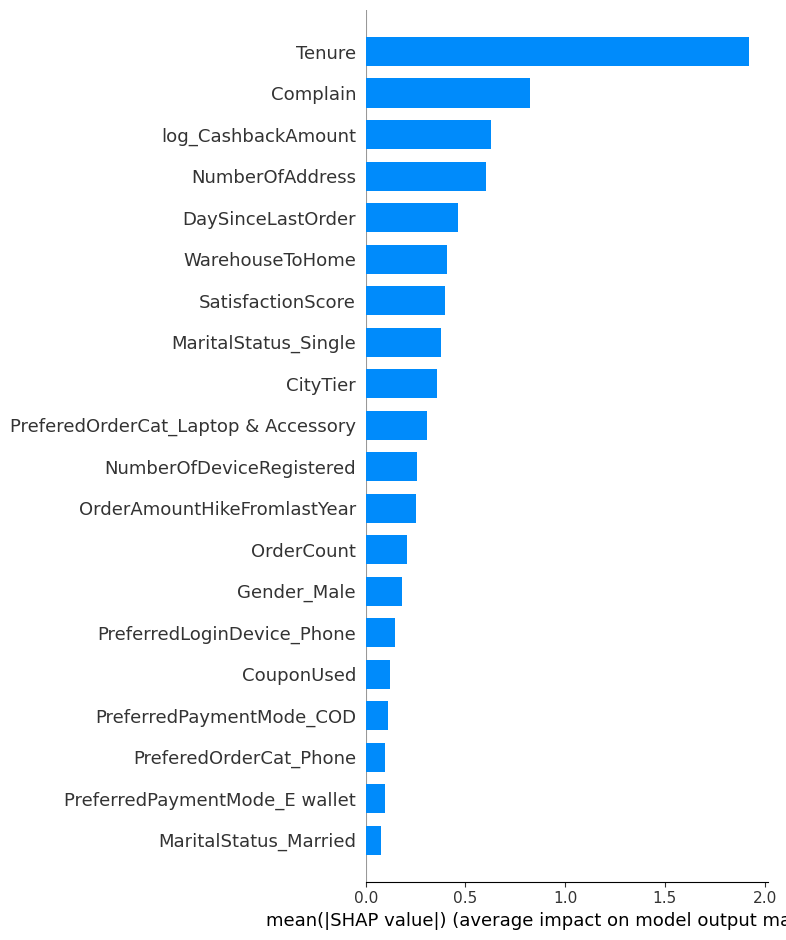

In [176]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar"
)

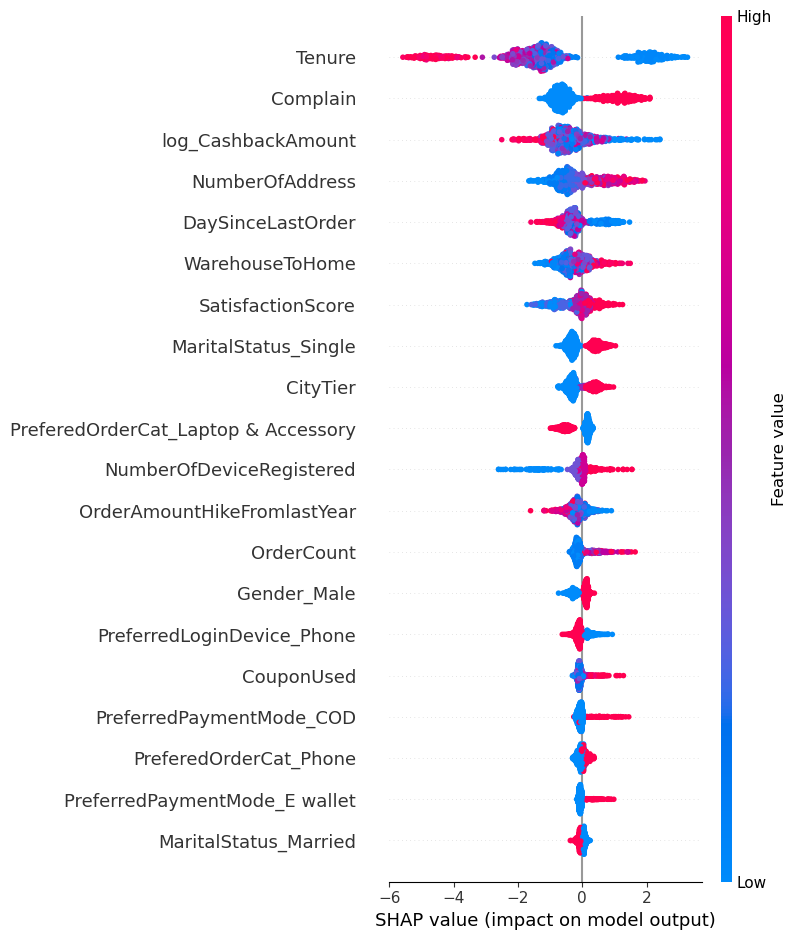

In [177]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names
)

The SHAP summary (beeswarm) plot provides insights into both the magnitude and direction of each feature’s 
impact on churn prediction.

- For **Tenure**, customers with lower tenure values (shown in blue) tend to have positive SHAP values, 
indicating an increased likelihood of churn. On the other hand, higher tenure values (in red) are associated 
with negative SHAP values, suggesting that long-term customers are less likely to churn.

- For **Complain**, customers who have submitted complaints (value = 1, shown in red) exhibit positive 
SHAP values, indicating a higher churn risk, while customers without complaints tend to have lower 
churn propensity.

Overall, the plot confirms that customer retention duration and service experience are critical factors 
in explaining churn behavior.

### **5.12 Save Final Model**

In [178]:
#best model
pipe_tuned


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder']),
                                                 ('log',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransform...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [179]:
#fitting
pipe_tuned.fit(X,y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder']),
                                                 ('log',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransform...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [180]:
#save pickle
pickle.dump(pipe_tuned, open('model_xgboost.sav', 'wb'))

In [181]:
#load model
model_load = pickle.load(open('model_xgboost.sav', 'rb'))
model_load

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder']),
                                                 ('log',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransform...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [182]:
df_predict = pd.DataFrame({
    'Tenure' : [0], 
    'PreferredLoginDevice' : ['Mobile Phone'], 
    'CityTier' : [3], 
    'WarehouseToHome' : [6.0], 
    'PreferredPaymentMode' : ['UPI'], 
    'Gender' : ['Male'], 
    'HourSpendOnApp' : [3.0],
    'NumberOfDeviceRegistered' : [2], 
    'PreferedOrderCat' : ['Laptop & Accessory'], 
    'SatisfactionScore' : [4], 
    'MaritalStatus' : ['Single'], 
    'NumberOfAddress' : [2], 
    'Complain' : [1],
    'OrderAmountHikeFromlastYear' : [0], 
    'CouponUsed' : [1.0], 
    'OrderCount' : [1.0], 
    'DaySinceLastOrder' : [2.0],
    'CashbackAmount' : [20.00]
    })

# print sample data
display(df_predict)

# predict that data
print("predict proba :",model_load.predict_proba(df_predict))
print("predict class :",model_load.predict(df_predict))

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,0,Mobile Phone,3,6.0000e+00,UPI,Male,3.0000e+00,2,Laptop & Accessory,4,Single,2,1,0,1.0000e+00,1.0000e+00,2.0000e+00,2.0000e+01


predict proba : [[0.47568297 0.524317  ]]
predict class : [1]


### **5.13 Business-Oriented Model Inference & Customer Prioritization**

#### **Mass Scoring on Holdout Dataset**

The trained model is applied to the holdout dataset to generate churn probability scores for each customer. 
Customer identifiers are re-attached post-prediction for business reference purposes and are not used during model training.

In [183]:
df_scored = X_test.copy()
df_scored['churn_proba'] = model_load.predict_proba(X_test)[:, 1]

df_scored['CustomerID'] = df_modelling.iloc[X_test.index]['CustomerID'].values

#### **Risk-Based Customer Ranking**

Customers are ranked in descending order of predicted churn probability. 
This ranking enables the business to identify high-risk customers and prioritize retention efforts accordingly.

In [184]:
df_ranked = df_scored.sort_values(
    by='churn_proba',
    ascending=False
).reset_index(drop=True)

In [185]:
df_ranked['churn_proba'].describe()

count   1.1260e+03
mean    2.0427e-01
std     3.5072e-01
min     2.4407e-05
25%     6.0679e-03
50%     2.4557e-02
75%     1.3904e-01
max     9.9943e-01
Name: churn_proba, dtype: float64

Below is an example of the top-ranked customers based on churn probability. 
These customers represent the highest churn risk segment and would be prioritized for retention interventions.

In [186]:
pd.options.display.float_format = '{:.6f}'.format
df_ranked[['CustomerID', 'churn_proba']].head(10)

,CustomerID,churn_proba
0,54288,0.999432
1,54023,0.998848
2,54618,0.998345
3,51803,0.998078
4,53751,0.997716
5,55229,0.997700
6,53697,0.997220
7,50339,0.996918
8,52094,0.996486
9,50936,0.995889


While the top-ranked customers show very high predicted probabilities, this is expected as they represent extreme high-risk cases. The overall probability distribution remains skewed toward low values due to class imbalance.

## **6. Conclusion & Recommendations**

### **6.1 Conclusion**

Our analysis reveals that churn in this dataset represents a forward-looking customer quality indicator, rather than a simple measure of customer departure. Customers flagged as "churned" are often still actively purchasing but exhibit patterns historically associated with eventual disengagement or low lifetime value. Therefore, churn within non-subscription e-commerce platforms like Flipkart should be treated not as a single observable event, but as a risk classification problem driven by behavioral, engagement, and experience signals.

Using historical customer data, an XGBoost classification model was developed to identify high-risk customers, enabling proactive retention decision-making rather than reactive revenue recovery. The final tuned model achieved strong predictive performance, particularly in recall — ensuring that high-risk customers are not missed. While this resulted in more false positives, the trade-off is acceptable given the low cost of unnecessary retention interventions compared to the cost of missing a churn-risk customer.

Importantly, the model functions as a decision-support system, allowing Flipkart to differentiate between customers who warrant retention attention and those who do not. In an environment where marketing interventions are costly and cannot be applied universally, this targeted identification of churn risk represents a meaningful operational advantage.

### **6.2 Recommendation**

#### Business Recommendation
##### **New Customer Retention Program**

* **Target Segment:** All new customers <= 3 months tenure
* **Rationale:** This window time is critical, 82% of our churned customer have tenure less than 3 months.

**Recommended Actions:**

1.  **Automated Welcome Messages:** Send personalized welcome emails or app notifications to new customers with personalized touchpoints at day 1, 7, 14, 30, 60, and 90.
    * **Objective:** Keep customer engaged to the firm.

2.  **Early Purchase Protection:** Offer extended return windows and proactive delivery tracking for early purchases to build trust.
    * **Objective:** New customers usually don't trust the platform yet, so by providing them with more security and reducing their risk, hopefully they build trust faster.

3.  **Milestone Rewards:** Provide a dual track incentives systems that rewards tenure duration and order count. the incentives could be discount or cashback.
    * **Objective:** Create a psychological incentive to stick around. Create a gamification effect.

4.  **Dedicated Support Channel:** Invert standard reward logic by assigning new customers to a priority queue. This ensures they receive faster responses from high-performing agents during their critical early period.
    * **Objective:** Protect new customers from bad experiences (complain). In this dataset, complain is the second most correlated feature to churn.

#### Machine Learning Recommendation
##### **1. Periodic Model Retraining**

* **Recommendation:** Retrain the model every 6 months using the most recent customer data.
* **Rationale:** Customer behavior evolves over time due to market trends, seasonal changes, and platform updates. A model trained on old data may lose accuracy (model drift) if not updated regularly.

##### **2. Feature Engineering for Model Enhancement**

* **Recommendation:** Incorporate additional features to improve model accuracy, particularly in the Monetary and Engagement dimensions.
* **Rationale:** The current dataset lacks comprehensive monetary indicators (only CashbackAmount is available). Adding features aligned with the RFM (Recency, Frequency, Monetary) framework would provide a more complete view of customer behavior.


##### **3. Batch Prediction for Streamlit Deployment**

* **Recommendation:** Upgrade the Streamlit app to support CSV batch upload for mass prediction.
* **Rationale:** The current single-record input is inefficient for marketing teams who need to score thousands of customers at once.

**Proposed Workflow:**
```
Input:  CSV file (customer data without churn flag)
           ↓
Output: CSV file (original data + churn prediction + probability score)
```